# Automated parameter selection for the switching Langevin model

This model's parameters (`a0, log_g0, g1_scale, a1_scale, sigma`) were
originally chosen by hand, in an earlier figure-generation script that is
no longer present in this repo: visually matching simulated curves against
the digitized curves on screen. This notebook replaces that manual step
with an automated fit against the real (non-digitized) grouped lifespan
data in `data/raw/` -- built specifically around this model's own
`dz = (a*z + g*z^2) dt + sigma dW` dynamics and simulator, rather than the
analytic Gompertz approximation or a general-purpose `(alpha, Z)`-
parameterized fit (those target a different pipeline's assumptions -- e.g.
a shared post-switch state for *both* Auxin conditions -- which don't
apply here, see Step 2 below). The only things reused from `src/` are the
simulator primitives this model needs (`model.simulate_fpt_and_state`,
`model.km_from_fpt`, `model.simulate_two_phase`) and plain data loading
(`data.py`) -- everything that actually decides *how the fit is done* is
written fresh below, against this exact model.

Three independent single/two-phase fits, one per condition:

- **DMSO_day_10** (single phase): fit `(a0, log_g0, sigma)` directly --
  the free 3-parameter case, since this is the one curve with no other
  condition's dynamics to borrow from.
- **Auxin_day_10** (single phase, own parameters): worms in this condition
  received the auxin treatment from day 0 -- they were *never* DMSO worms
  at any observed age, unlike Auxin_day_21. So this condition gets its own
  independent `(a0_auxin10, log_g0_auxin10)`, fit the same way as DMSO, not
  expressed as a switch from DMSO's dynamics and not tied to `g1_scale`/
  `a1_scale` at all. `sigma` is held fixed at the DMSO fit's value
  (assumed to be an intrinsic, shared property of the organism/environment,
  not something the intervention changes).
- **Auxin_day_21** (two phase): the only condition that actually *is* a
  DMSO worm up to its switch day -- so this is the only place
  `(g1_scale, a1_scale)` are fit, using this model's own parameterization
  (`a1 = a0*a1_scale`, `log_g1 = g1_scale*log_g0`), with phase 1 fixed at
  DMSO's own fitted `(a0, log_g0)` and `sigma` fixed throughout.

Each fit is validated against the real Kaplan-Meier curve, both visually
and via RMSE/KS (`metrics.goodness_of_fit` -- a plain evaluation metric,
not a fitting method, reused here as-is).

**To try different assumptions** (a wider `Z_H_RANGE`, a stricter
`GAMMA_MIN`, different optimizer bounds, ...): edit the "Configuration"
cell below, then Run All. Every other cell reads its settings from there
rather than hardcoding its own copy, so one edit propagates through every
diagnostic plot and both fitting steps consistently.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.optimize import differential_evolution, minimize

warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
SRC_DIR = NOTEBOOK_DIR.parent / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from model import (
    km_from_fpt,
    simulate_fpt_and_state,
    simulate_two_phase,
    simulate_two_phase_trajectories,
)
from metrics import goodness_of_fit
from data import kaplan_meier_curve, load_raw_survival_data, weight_at_times

matplotlib.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

raw_data = load_raw_survival_data()


def make_curve_dict(name):
    """(t_emp, S_emp, weight_emp, t_max) for one condition, straight off its
    real per-worm data -- same shape used throughout this notebook.

    Also carries `death_weight_emp`/`censor_weight_emp` (weight split by
    event type at each `t_emp`, rather than `weight_emp`'s combined total)
    -- needed by `_weighted_neg_log_lik` below, which needs death and
    censoring events at the same age handled as separate contributions,
    not lumped into one per-age weight."""
    d = raw_data[name]
    kmf = kaplan_meier_curve(d)
    t_unique = np.unique(d.t)
    S_emp = kmf.survival_function_at_times(t_unique).to_numpy()
    weight_emp = weight_at_times(d, t_unique)
    death_weight_emp = np.array([d.weight[(d.t == t) & (d.event_observed == 1)].sum() for t in t_unique])
    censor_weight_emp = weight_emp - death_weight_emp
    return {"t_emp": t_unique, "S_emp": S_emp, "weight_emp": weight_emp,
            "death_weight_emp": death_weight_emp, "censor_weight_emp": censor_weight_emp,
            "t_max": float(d.t.max()), "n_total": d.n_total, "kmf": kmf}


dmso_curve = make_curve_dict("DMSO_day_10")
auxin10_curve = make_curve_dict("Auxin_day_10")
auxin21_curve = make_curve_dict("Auxin_day_21")

## Configuration -- edit these, then Run All

Every tunable knob used anywhere below lives here, in one place. Testing a
different assumption is "change a number in this cell, Run All" -- no
hunting through later sections for a second copy of the same constant.
Grouped by what each group controls; see the comment on each constant.

In [2]:
# --- Plausibility criteria (Step 0) ---------------------------------------
# What "biologically plausible" means, in terms of the two derived
# quantities that actually carry meaning: z_m = sigma/sqrt(a) (typical/
# "healthy" state scale) and z_h = a/g (absorbing/toxicity threshold).
# Historical note: these ranges were originally chosen to bracket an early
# exploratory notebook's MLE fit (Z_dmso ~ 47) and its Z_AUXIN_CAP=80; that
# notebook is no longer present in this repo. This notebook is now the
# leading, self-contained source for these values -- see Step 0's markdown
# below for the full derivation from this notebook's own diagnostics.
Z_M_RANGE = (4.0, 10.0)    # plausible "healthy state" scale
Z_H_RANGE = (40.0, 60.0)   # plausible toxicity threshold (matches Z_AUXIN_CAP=80)
GAMMA_MIN = 50.0           # weak-nonlinearity/Gompertzian regime, Eq. B12 (paper wants >> 1)

# --- Model constants --------------------------------------------------------
T_SWITCH_21 = 21.0   # Auxin_day_21's intervention day

# --- Diagnostic grid resolutions / sweep ranges (Step 0) -------------------
PLAUSIBLE_GRID_N = 2000                            # (a0, log_g0) plausibility heatmap resolution, per axis
BASELINE_SIGMA_SLICES = [0.4, 0.8, 1.2, 1.6]       # sigma values for the first 4-panel plausibility plot
INTERVENTION_GRID_N = 200                          # (a1_scale, g1_scale) plausibility grid resolution, per axis
N_BASELINE_POINTS = 5                              # baseline (a0, log_g0) points sampled per sigma, for the
                                                    # intersection / reachable-region plots
INTERSECTION_SIGMA_SLICES = [0.6, 0.8, 1.0, 1.2]   # sigma values for the intersection / reachable-region /
                                                    # z_m1-z_h1-range plots
N_LOSS_GRID = 12                                   # loss-landscape grid resolution, per axis (each grid point
                                                    # runs an actual simulation, so keep this modest)
LOSS_MARGIN = 0.5                                  # log-space margin outside the plausible band, for
                                                    # loss-landscape context
SIGMA_LOSS_SWEEP = np.linspace(0.1, 1.0, 10)       # sigma values for the 10-panel DMSO loss-landscape sweep
N_BOUNDARY_GRID = 300                              # fine-resolution grid for tracing the (a1_scale, g1_scale)
                                                    # plausibility boundary line (pure algebra, cheap -- can be
                                                    # much finer than N_LOSS_GRID)
A1_SCALE_LOSS_RANGE = (0.2, 1.6)                   # (a1_scale, g1_scale) axis ranges for the intervention
G1_SCALE_LOSS_RANGE = (0.6, 1.8)                   # loss-landscape plots

# --- Optimizer outer-box bounds (Steps 1, 1b, 2) ----------------------------
# Deliberately loose -- they just need to comfortably contain the plausible
# region. is_plausible_baseline/is_plausible_intervention (hard constraints,
# see "Shared fitting machinery" below) do the actual shaping of the
# feasible region, not these boxes -- see Step 1's markdown for why.
A_BOUNDS = (0.02, 1.0)
LOG_G_BOUNDS = (-5.0, -0.5)
SIGMA_BOUNDS = (0.2, 2.0)
A1_SCALE_BOUNDS = (0.1, 2.5)
G1_SCALE_BOUNDS = (0.1, 2.5)

# --- Validation / trajectory-plot settings ----------------------------------
# DT_TRAJ/DT_VALIDATE both match the dt actually used by fit_single_phase/
# fit_two_phase_scale above (dt=0.1) -- keeping every simulation in this
# project on the same step size rather than a finer one used only for
# plotting, which would silently make plotted trajectories/curves a
# slightly different (if more accurate) simulation than the one that was
# actually fit.
N_TRAJ = 40          # trajectories drawn in the DMSO -> Auxin_day_21 trajectory plot
DT_TRAJ = 0.1
N_VALIDATE = 4000    # particles simulated for the final fitted-vs-real-KM validation plot
DT_VALIDATE = 0.1

## Shared fitting machinery

The switching Langevin model, nothing more: `dz = (a*z + g*z^2) dt + sigma
dW`, absorbing wall at `z_h = a/g` (`g = 10**log_g`), simulated by
`model.simulate_fpt_and_state` and turned into first-passage times fed
directly to `_weighted_neg_log_lik`. Both fitting functions below share
the same MLE (Monte-Carlo negative-log-likelihood, `_weighted_neg_log_lik`
-- see its definition above for the derivation) objective and two-stage
(global search + local polish) optimization pattern, common random
numbers included, so the optimizer objective is smooth in the parameters
rather than jumping around from fresh Monte Carlo noise at every
evaluation. `_weighted_log_loss` below is kept as an alternative,
non-default objective (a weighted least-squares fit against the empirical
KM curve's values, rather than a likelihood) for comparison against
`_weighted_neg_log_lik`.

Both also take an optional `plausible_fn(params) -> bool`: when given, the
objective returns `inf` immediately for any parameter combination that
fails it, **before** running the simulation at all -- a hard constraint,
not a soft penalty. This matters: a soft penalty still lets the optimizer
trade off fit quality against implausibility (a big enough loss
improvement can outweigh any finite penalty), which is exactly how the
earlier unconstrained fit ended up at `z_h=321,772` -- it fit `S(t)`
slightly better than anything inside the plausible region did, so a soft
penalty would only have discouraged that corner, not ruled it out. An
`inf` return can't be outweighed by anything, so a degenerate point is
never selected regardless of how much better its raw loss looks -- defined
before Step 0 since Step 0's loss-landscape section below needs it too.

In [3]:
def _make_common_noise(n_paths, dt, t_max, seed):
    n_steps = int(round(t_max / dt))
    return np.random.default_rng(seed).standard_normal((n_paths, n_steps))


def _weighted_log_loss(S_sim, S_emp, weight_emp, n_paths):
    floor = 1.0 / (n_paths + 1)
    log_sim = np.log(np.clip(S_sim, floor, 1.0))
    log_emp = np.log(np.clip(S_emp, floor, 1.0))
    return float(np.sum(np.asarray(weight_emp, dtype=float) * (log_sim - log_emp) ** 2))

### An MLE-style alternative to `_weighted_log_loss`

`_weighted_log_loss` is a weighted least-squares fit against the empirical
KM curve's own values -- not a likelihood. A real MLE loss for the
closed-form single-phase/Gompertz case is possible too (each observed
death contributes its probability *density*, each censored worm its
survival *probability*, straight from `data.load_raw_survival_data()`'s
grouped death/censor rows -- no curve-reconstruction step in between), but
no such closed-form implementation is currently in `src/`. The two-phase
switching model has no closed-form density to plug into that same formula
either way (the handed-off `z` distribution at the switch isn't
analytic), but a Monte Carlo analogue is still possible: replace the
continuous density
`f(t_i)` with the *interval probability mass* `S_sim(t_(i-1)) -
S_sim(t_i)` estimated from the simulated first-passage times' own KM
curve (`t_(0) = 0`, `S_sim(0) = 1` by construction) -- the discrete-time/
life-table version of the same likelihood, using exactly the same
`(t, event_observed, weight)` grouped data as the closed-form models, not
a reconstructed curve.

This is provided as an additional, available objective -- **not** wired
into `fit_single_phase`/`fit_two_phase_scale` by default, since doing so
would change every fitted value in this notebook again and should be a
deliberate choice, not a side effect of adding it.

In [4]:
def _weighted_neg_log_lik(T_sim, cond, n_paths):
    """
    Monte-Carlo analogue of a grouped-data negative log-likelihood, for a
    model with no closed-form survival function:

        log L = sum_i [death_weight_i * log(S(t_(i-1)) - S(t_i))
                      + censor_weight_i * log(S(t_i))]

    with t_(0)=0, S(0)=1 by construction, S(.) the simulated model's own
    Kaplan-Meier curve (model.km_from_fpt) built from T_sim (this
    condition's simulated first-passage times, n_paths of them). Each
    observed death in (t_(i-1), t_i] contributes the probability *mass* of
    dying in that interval (there is no continuous density to evaluate
    pointwise from a finite Monte Carlo sample); each censored worm at t_i
    contributes the probability of surviving at least to t_i -- exactly the
    analytic model's likelihood, with intervals standing in for a density.

    T_sim: first-passage times from n_paths simulated worms (model.py's
    convention: T == t_max for survivors, i.e. censored).
    cond: a make_curve_dict()-style dict -- needs "t_emp", "t_max",
    "death_weight_emp", "censor_weight_emp".

    Returns the *negative* log-likelihood (lower is better), same
    "lower is better" convention as _weighted_log_loss, so it drops in as a
    direct replacement.
    """
    t_grid = np.concatenate(([0.0], cond["t_emp"]))
    S_grid = km_from_fpt(T_sim, t_grid, t_max=cond["t_max"])

    floor = 1.0 / (n_paths + 1)
    S_grid = np.clip(S_grid, floor, 1.0)
    interval_mass = np.clip(S_grid[:-1] - S_grid[1:], floor, None)

    log_lik = np.sum(cond["death_weight_emp"] * np.log(interval_mass)
                      + cond["censor_weight_emp"] * np.log(S_grid[1:]))
    if not np.isfinite(log_lik):
        return np.inf
    return -float(log_lik)


def fit_single_phase(
    cond, a_bounds, log_g_bounds, sigma_bounds=None, sigma_fixed=None,
    dt=0.1, n_paths_search=600, n_paths_final=3000, seed=42, de_kwargs=None,
    plausible_fn=None,
):
    """
    Fit a single-phase population's `(a, log_g[, sigma])` directly against
    its own real KM curve. If `sigma_fixed` is given, `sigma` is held there
    and only `(a, log_g)` are free (bounds must then be just the 2 pairs).

    plausible_fn: optional `(a, log_g, sigma) -> bool` hard constraint (see
    module markdown above) -- e.g. `is_plausible_baseline`.

    Returns {"a", "log_g", "sigma", "loss", "search_result", "local_result"}.
    """
    free_sigma = sigma_fixed is None
    bounds = [a_bounds, log_g_bounds] + ([sigma_bounds] if free_sigma else [])
    de_kwargs = dict(de_kwargs or {})
    de_kwargs.setdefault("maxiter", 40)
    de_kwargs.setdefault("popsize", 12)
    de_kwargs.setdefault("polish", False)
    de_kwargs.setdefault("seed", seed)

    def unpack(params):
        if free_sigma:
            return params
        a, log_g = params
        return a, log_g, sigma_fixed

    def build_objective(n_paths, noise):
        def objective(params):
            a, log_g, sigma = unpack(params)
            if plausible_fn is not None and not plausible_fn(a, log_g, sigma):
                return np.inf
            g = 10.0 ** log_g
            z_h = a / g
            try:
                T, _, _ = simulate_fpt_and_state(
                    n_paths, a, g, sigma ** 2, z_h, z0=0.0, dt=dt,
                    t_max=cond["t_max"], noise=noise,
                )
            except (FloatingPointError, ValueError):
                return np.inf
            if not np.all(np.isfinite(T)):
                return np.inf
            loss = _weighted_neg_log_lik(T, cond, n_paths)
            return loss if np.isfinite(loss) else np.inf

        return objective

    noise_s = _make_common_noise(n_paths_search, dt, cond["t_max"], seed=seed)
    de_result = differential_evolution(build_objective(n_paths_search, noise_s), bounds, **de_kwargs)

    noise_f = _make_common_noise(n_paths_final, dt, cond["t_max"], seed=seed + 1000)
    local_result = minimize(
        build_objective(n_paths_final, noise_f), x0=de_result.x, method="Nelder-Mead",
        bounds=bounds, options={"xatol": 1e-4, "fatol": 1e-6, "maxiter": 300},
    )

    best_params = local_result.x if local_result.fun <= de_result.fun else de_result.x
    best_loss = min(local_result.fun, de_result.fun)
    a, log_g, sigma = unpack(best_params)
    if not np.isfinite(best_loss):
        raise RuntimeError(
            f"fit_single_phase found no plausible parameter combination anywhere in "
            f"bounds={bounds} -- every evaluation returned inf, so the returned "
            f"(a={a:.4g}, log_g={log_g:.4g}, sigma={sigma:.4g}) is meaningless, not a "
            f"real fit. Likely cause: the plausible region (from plausible_fn) is "
            f"empty or too small a fraction of this box for the optimizer to find. "
            f"Check Z_M_RANGE/Z_H_RANGE/GAMMA_MIN against these bounds (use "
            f"tight_baseline_box to derive a box that actually wraps the plausible "
            f"region), or widen them."
        )
    return {"a": a, "log_g": log_g, "sigma": sigma, "loss": best_loss,
            "search_result": de_result, "local_result": local_result}


def fit_two_phase_scale(
    a0, log_g0, sigma, t_switch, cond, a1_scale_bounds, g1_scale_bounds,
    dt=0.1, n_paths_search=600, n_paths_final=3000, seed=42, de_kwargs=None,
    plausible_fn=None,
):
    """
    Fit `(a1_scale, g1_scale)` for the post-switch phase of this notebook's
    two-stage model, using its exact parameterization: `a1 = a0*a1_scale`,
    `log_g1 = g1_scale*log_g0` (equivalently `g1 = g0**g1_scale`). Phase 1
    stays fixed at `(a0, log_g0)`; `sigma` is fixed throughout.

    plausible_fn: optional `(a1_scale, g1_scale) -> bool` hard constraint --
    e.g. `is_plausible_intervention` partially applied to this baseline.

    Returns {"a1_scale", "g1_scale", "a1", "g1", "z_h1", "loss",
    "search_result", "local_result"}.
    """
    g0 = 10.0 ** log_g0
    z_h0 = a0 / g0
    bounds = [a1_scale_bounds, g1_scale_bounds]
    de_kwargs = dict(de_kwargs or {})
    de_kwargs.setdefault("maxiter", 40)
    de_kwargs.setdefault("popsize", 12)
    de_kwargs.setdefault("polish", False)
    de_kwargs.setdefault("seed", seed)

    def derived(params):
        a1_scale, g1_scale = params
        a1 = a0 * a1_scale
        g1 = g0 ** g1_scale
        return a1, g1, a1 / g1

    def build_objective(n_paths, noise1, noise2):
        def objective(params):
            if plausible_fn is not None and not plausible_fn(*params):
                return np.inf
            a1, g1, z_h1 = derived(params)
            try:
                T = simulate_two_phase(
                    n_paths, a0, z_h0, a1, z_h1, sigma ** 2, t_switch, cond["t_max"], dt,
                    noise1=noise1, noise2=noise2,
                )
            except (FloatingPointError, ValueError):
                return np.inf
            if not np.all(np.isfinite(T)):
                return np.inf
            loss = _weighted_neg_log_lik(T, cond, n_paths)
            return loss if np.isfinite(loss) else np.inf

        return objective

    noise1_s = _make_common_noise(n_paths_search, dt, t_switch, seed=seed)
    noise2_s = _make_common_noise(n_paths_search, dt, cond["t_max"] - t_switch, seed=seed + 1)
    de_result = differential_evolution(build_objective(n_paths_search, noise1_s, noise2_s), bounds, **de_kwargs)

    noise1_f = _make_common_noise(n_paths_final, dt, t_switch, seed=seed + 1000)
    noise2_f = _make_common_noise(n_paths_final, dt, cond["t_max"] - t_switch, seed=seed + 1001)
    local_result = minimize(
        build_objective(n_paths_final, noise1_f, noise2_f), x0=de_result.x, method="Nelder-Mead",
        bounds=bounds, options={"xatol": 1e-4, "fatol": 1e-6, "maxiter": 300},
    )

    best_params = local_result.x if local_result.fun <= de_result.fun else de_result.x
    best_loss = min(local_result.fun, de_result.fun)
    a1_scale, g1_scale = best_params
    a1, g1, z_h1 = derived(best_params)
    if not np.isfinite(best_loss):
        raise RuntimeError(
            f"fit_two_phase_scale found no plausible (a1_scale, g1_scale) anywhere in "
            f"bounds={bounds} -- every evaluation returned inf, so the returned "
            f"(a1_scale={a1_scale:.4g}, g1_scale={g1_scale:.4g}) is meaningless, not a "
            f"real fit. Likely cause: this baseline's own z_h0={z_h0:.4g} leaves little "
            f"or no room below the plausibility ceiling for z_h1 to satisfy "
            f"z_h0 <= z_h1 <= z_h_max -- check how close z_h0 is to that ceiling "
            f"(use tight_intervention_box to derive a box that actually wraps the "
            f"plausible region), or widen Z_H_RANGE."
        )
    return {"a1_scale": a1_scale, "g1_scale": g1_scale, "a1": a1, "g1": g1, "z_h1": z_h1,
            "loss": best_loss, "search_result": de_result, "local_result": local_result}

## Step 0 -- which `(a0, log_g0, sigma)` combinations are even plausible?

Before fitting anything: map out which parameter combinations give
*physically sensible* derived quantities, rather than letting an
unconstrained box search wander into a corner that fits `S(t)` well but
implies nonsense trajectories -- exactly what happened before this
notebook enforced `Z_M_RANGE`/`Z_H_RANGE`/`GAMMA_MIN` (`z_h` reaching into
the hundreds of thousands). The two derived quantities that actually carry
biological meaning:

- `z_m = sigma/sqrt(a)` (equivalently `sqrt(sigma_sq/a)`): the state's
  typical/"healthy" fluctuation scale -- this is the diffusive-width scale
  from Podolskiy et al. (arXiv:1502.04307), Appendix B, the crossover
  `z >> sqrt(Delta/alpha)` following Eq. (B19) (`Delta` there = our
  `sigma_sq`; also cross-checked via the Fokker-Planck flux, Eq. B1,
  `J = vP - (Delta/2) dP/dz`). **Not** `sigma/a` -- that was this
  notebook's own bug for several iterations (caught by inspection against
  an earlier exploratory notebook's already-correct
  `z* = sqrt(sigma_sq/alpha)`), now fixed everywhere `z_m` is computed
  below.
- `z_h = a/g`: the absorbing/toxicity threshold.

An earlier, exploratory notebook (no longer present in this repo) found
`Z_dmso ~ 47` via its own closed-form MLE fit, matching its stated
biological expectation ("healthy state near 0-10, ~5x that for the
toxicity threshold, i.e. ~50"), and used `Z_AUXIN_CAP=80` as the
post-intervention threshold's outer limit -- the defaults for
`Z_M_RANGE`/`Z_H_RANGE` in the Configuration cell above originated from
those same numbers rather than inventing new ones, but are now this
notebook's own fixed configuration, not a live dependency. After the
intervention, both
barriers are expected to move *up* (`z_m1 >= z_m0`, `z_h1 >= z_h0` -- a
less noise-dominated, more toxicity-resistant worm) while staying under
that same outer limit.

In [5]:
def is_plausible_baseline(a, log_g, sigma):
    g = 10.0 ** log_g
    z_m, z_h = sigma / np.sqrt(a), a / g
    gamma = a * z_h ** 2 / sigma ** 2
    return (Z_M_RANGE[0] <= z_m <= Z_M_RANGE[1]) and (Z_H_RANGE[0] <= z_h <= Z_H_RANGE[1]) and (gamma >= GAMMA_MIN)

### Grid: `(a0, log_g0)` plausibility, one slice per representative `sigma`

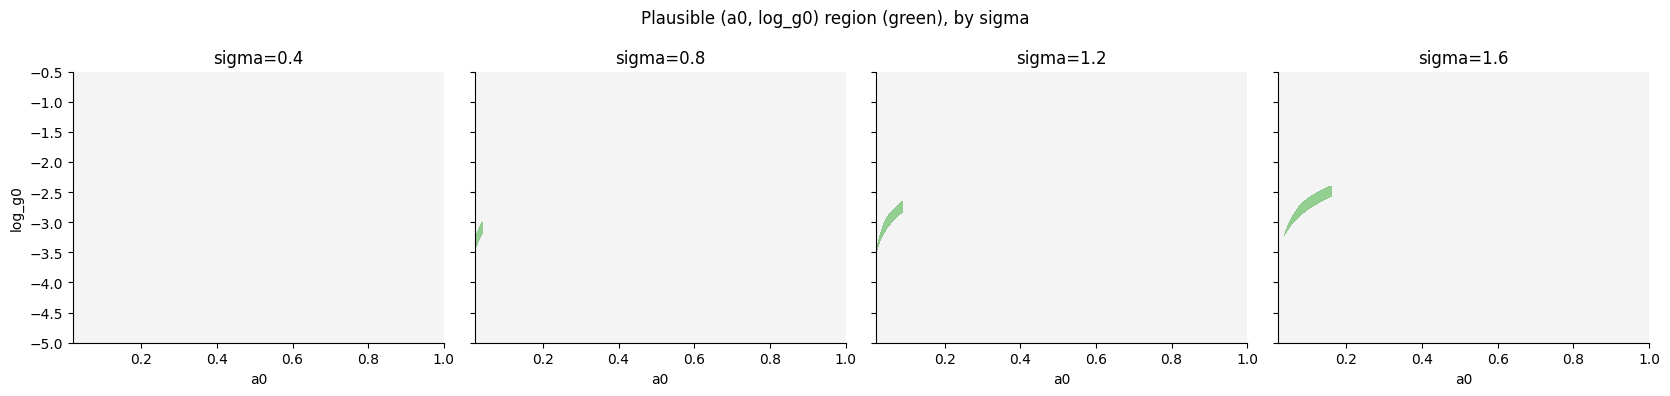

In [6]:
a_grid = np.linspace(0.02, 1.0, PLAUSIBLE_GRID_N)
log_g_grid = np.linspace(-5.0, -0.5, PLAUSIBLE_GRID_N)
A, LOG_G = np.meshgrid(a_grid, log_g_grid)

fig0, axes0 = plt.subplots(1, len(BASELINE_SIGMA_SLICES), figsize=(4.2 * len(BASELINE_SIGMA_SLICES), 4), sharey=True)
for ax, sig in zip(axes0, BASELINE_SIGMA_SLICES):
    G = 10.0 ** LOG_G
    Z_M, Z_H = sig / np.sqrt(A), A / G
    GAMMA = A * Z_H ** 2 / sig ** 2
    plausible = (
        (Z_M >= Z_M_RANGE[0]) & (Z_M <= Z_M_RANGE[1])
        & (Z_H >= Z_H_RANGE[0]) & (Z_H <= Z_H_RANGE[1])
        & (GAMMA >= GAMMA_MIN)
    )
    ax.contourf(A, LOG_G, plausible, levels=[-0.5, 0.5, 1.5], colors=["#eeeeee", "#4daf4a"], alpha=0.6)
    ax.set_title(f"sigma={sig}")
    ax.set_xlabel("a0")
    if sig == BASELINE_SIGMA_SLICES[0]:
        ax.set_ylabel("log_g0")
fig0.suptitle("Plausible (a0, log_g0) region (green), by sigma")
plt.tight_layout()
plt.show()

### Closed-form boundary

The plausible region isn't an axis-aligned box in `(a0, log_g0)` -- it's a
diagonal band, because `z_h = a/g` ties `log_g0` to `a0` directly (visible
above: the green region tilts, it isn't a rectangle). Solving each
inequality for the free variable gives the exact boundary, no grid search
actually required once you see this:

- `z_m = sigma/sqrt(a)` in `Z_M_RANGE` => `sqrt(a)` in `[sigma/Z_M_RANGE[1],
  sigma/Z_M_RANGE[0]]` => `a` in `[(sigma/Z_M_RANGE[1])**2, (sigma/Z_M_RANGE[0])**2]`
  (squaring preserves the ordering since both sides are positive).
- `z_h = a/g` in `Z_H_RANGE`, i.e. `log_g = log10(a/z_h)` =>
  `log_g0` in `[log10(a) - log10(Z_H_RANGE[1]), log10(a) - log10(Z_H_RANGE[0])]`
  -- a band whose *center* shifts with `a0`, not a fixed pair of bounds.

This is exactly why an independent box on `(a0, log_g0)` alone would let a
search wander into a degenerate corner: fixing `log_g0`'s bounds without
reference to `a0` allows combinations far off this band. The fix used in
Step 1 below is to bound `(a0, z_h0)` directly and *derive*
`log_g0 = log10(a0/z_h0)` inside the objective, rather than bounding
`(a0, log_g0)` independently.

In [7]:
def a_bounds_from_zm(sigma, z_m_range):
    return (sigma / z_m_range[1]) ** 2, (sigma / z_m_range[0]) ** 2


def log_g_bounds_from_a_zh(a, z_h_range):
    return np.log10(a / z_h_range[1]), np.log10(a / z_h_range[0])


def tight_baseline_box(z_m_range, z_h_range, sigma_bounds=None, sigma_fixed=None):
    """
    A tight `(a_bounds, log_g_bounds)` outer search box that comfortably
    wraps the *entire* plausible region for either a fixed `sigma` or a
    `sigma` range, built from the same closed-form corner logic as
    `a_bounds_from_zm`/`log_g_bounds_from_a_zh` above -- exact and free (no
    search), and always self-consistent with whatever `Z_M_RANGE`/
    `Z_H_RANGE`/`SIGMA_BOUNDS` are currently configured.

    Why this matters: a *generic* wide box (e.g. a fixed `(0.02, 1.0)` for
    `a`) can be enormously larger than the true plausible region once
    `Z_M_RANGE`/`Z_H_RANGE` are narrowed -- e.g. `Z_M_RANGE=(4,10),
    Z_H_RANGE=(20,60)` shrinks the plausible fraction of that generic box
    to a sliver. `differential_evolution`'s population is sampled
    (quasi-)randomly across whatever box it's given, so if the box is far
    bigger than the plausible region, its default-size population can
    easily contain *zero* plausible points -- every evaluation returns
    `inf`, and the optimizer silently "converges" to a meaningless point
    with `loss=inf`, which then poisons every downstream cell (this is
    exactly what happens with the narrow-bounds example above; see the
    finite-loss check added to `fit_single_phase`/`fit_two_phase_scale`
    below, which now catches this loudly instead). Searching this tight box
    instead makes the plausible region a large fraction of what's actually
    searched, so the random population reliably contains feasible points.
    """
    if sigma_fixed is not None:
        a_lo, a_hi = a_bounds_from_zm(sigma_fixed, z_m_range)
    else:
        sig_lo, sig_hi = sigma_bounds
        a_lo = a_bounds_from_zm(sig_lo, z_m_range)[0]
        a_hi = a_bounds_from_zm(sig_hi, z_m_range)[1]
    log_g_lo = log_g_bounds_from_a_zh(a_lo, z_h_range)[0]
    log_g_hi = log_g_bounds_from_a_zh(a_hi, z_h_range)[1]
    return (a_lo, a_hi), (log_g_lo, log_g_hi)

### Same question for the intervention: `(a1_scale, g1_scale)`

`is_plausible_intervention` checks the reviewer's other stated
expectation: both barriers move *up* after the intervention (`z_m1 >=
z_m0`, `z_h1 >= z_h0`) while `z_h1` stays under the same outer limit as
the baseline (`Z_H_RANGE`'s upper end, i.e. `Z_AUXIN_CAP=80`). Since Step
0's own closed form describes a whole *band* of plausible baselines, not
a single point, checking this at just one `(a0, log_g0)` wouldn't say
much about whether an `(a1_scale, g1_scale)` bound picked there still
holds elsewhere in that band -- so we go straight to the generalized,
multi-baseline-point version below rather than a single-point plot first.

`intervention_plausible_mask` below is `is_plausible_intervention` rewritten
to take a `(a0, log_g0)` array pair instead of one number, so it can be
evaluated at many baseline points on the same `(a1_scale, g1_scale)` grid
and the results overlaid. `baseline_band_points` samples `n_a0` points
evenly across the plausible `a0` interval at a given `sigma` (each paired
with the midpoint of *its own* plausible `log_g0` interval, from the
closed form above) -- i.e. it walks across the whole diagonal band shown
in the Step 0 plausibility plot above, not just a single point in it.

For each of `INTERSECTION_SIGMA_SLICES`: sample `N_BASELINE_POINTS`
baseline points, plot each one's own plausible-region *outline*, and shade
their **intersection** -- the `(a1_scale, g1_scale)` region that stays
valid no matter which point in the baseline band the Step 1 fit actually
lands on. That intersection is the right thing to hand to Step 2 as a
bound, since we don't yet know exactly where in the band the data-driven
fit will land.

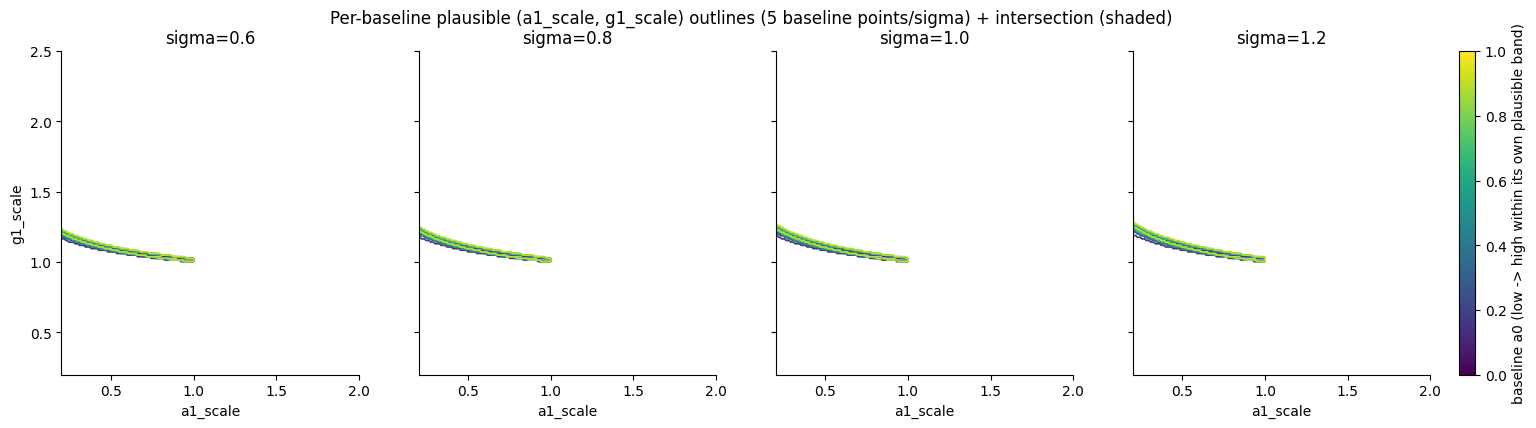

Per-sigma intersection region (valid for every sampled baseline point):
  sigma=0.6:  a1_scale in (0.462, 0.996),  g1_scale in (1.009, 1.102)  (covers 0.2% of the grid)
  sigma=0.8:  a1_scale in (0.489, 0.996),  g1_scale in (1.009, 1.102)  (covers 0.2% of the grid)
  sigma=1.0:  a1_scale in (0.517, 0.996),  g1_scale in (1.009, 1.102)  (covers 0.2% of the grid)
  sigma=1.2:  a1_scale in (0.535, 0.996),  g1_scale in (1.009, 1.102)  (covers 0.2% of the grid)


In [8]:
def is_plausible_intervention(a1_scale, g1_scale, a0, log_g0, sigma, z_h_max):
    g0 = 10.0 ** log_g0
    z_m0, z_h0 = sigma / np.sqrt(a0), a0 / g0
    a1, g1 = a0 * a1_scale, g0 ** g1_scale
    z_m1, z_h1 = sigma / np.sqrt(a1), a1 / g1
    return (z_m1 >= z_m0) and (z_h0 <= z_h1 <= z_h_max)


a1_scale_grid = np.linspace(0.2, 2.0, INTERVENTION_GRID_N)
g1_scale_grid = np.linspace(0.2, 2.5, INTERVENTION_GRID_N)
A1S, G1S = np.meshgrid(a1_scale_grid, g1_scale_grid)


def baseline_band_points(sigma, n_a0=N_BASELINE_POINTS, z_m_range=Z_M_RANGE, z_h_range=Z_H_RANGE):
    """n_a0 representative (a0, log_g0) points spanning the plausible band at
    a given sigma: evenly spaced a0 across its z_m-plausible interval, each
    paired with the midpoint of its own z_h-plausible log_g0 interval."""
    a_lo, a_hi = a_bounds_from_zm(sigma, z_m_range)
    a0_vals = np.linspace(a_lo, a_hi, n_a0)
    return [(a0, 0.5 * sum(log_g_bounds_from_a_zh(a0, z_h_range))) for a0 in a0_vals]


def intervention_plausible_mask(a0, log_g0, sigma, A1S, G1S, z_h_max):
    """Same rule as is_plausible_intervention, vectorized over the
    (A1S, G1S) grid for one fixed (a0, log_g0, sigma) baseline."""
    g0 = 10.0 ** log_g0
    z_m0, z_h0 = sigma / np.sqrt(a0), a0 / g0
    A1, G1 = a0 * A1S, g0 ** G1S
    Z_M1, Z_H1 = sigma / np.sqrt(A1), A1 / G1
    return (Z_M1 >= z_m0) & (Z_H1 >= z_h0) & (Z_H1 <= z_h_max)


cmap = matplotlib.colormaps["viridis"]

fig0c, axes0c = plt.subplots(
    1, len(INTERSECTION_SIGMA_SLICES), figsize=(4.6 * len(INTERSECTION_SIGMA_SLICES), 4.2), sharex=True, sharey=True,
)
band_summary = {}

for ax, sig in zip(axes0c, INTERSECTION_SIGMA_SLICES):
    points = baseline_band_points(sig)
    masks = [intervention_plausible_mask(a0, log_g0, sig, A1S, G1S, Z_H_RANGE[1]) for a0, log_g0 in points]
    intersection = np.logical_and.reduce(masks)

    for (a0, log_g0), mask, color in zip(points, masks, cmap(np.linspace(0.15, 0.9, len(points)))):
        ax.contour(A1S, G1S, mask, levels=[0.5], colors=[color], linewidths=1.2)
    ax.contourf(A1S, G1S, intersection, levels=[0.5, 1.5], colors=["black"], alpha=0.25)

    ax.set_title(f"sigma={sig}")
    ax.set_xlabel("a1_scale")
    band_summary[sig] = {"points": points, "intersection_frac": float(intersection.mean())}
    if intersection.any():
        band_summary[sig]["a1_scale_range"] = (float(A1S[intersection].min()), float(A1S[intersection].max()))
        band_summary[sig]["g1_scale_range"] = (float(G1S[intersection].min()), float(G1S[intersection].max()))

axes0c[0].set_ylabel("g1_scale")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=matplotlib.colors.Normalize(vmin=0, vmax=1))
cbar = fig0c.colorbar(sm, ax=axes0c, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label("baseline a0 (low -> high within its own plausible band)")
fig0c.suptitle(
    f"Per-baseline plausible (a1_scale, g1_scale) outlines ({N_BASELINE_POINTS} baseline points/sigma) "
    "+ intersection (shaded)"
)
plt.show()

print("Per-sigma intersection region (valid for every sampled baseline point):")
for sig, info in band_summary.items():
    if "a1_scale_range" in info:
        print(f"  sigma={sig}:  a1_scale in {tuple(round(x, 3) for x in info['a1_scale_range'])},  "
              f"g1_scale in {tuple(round(x, 3) for x in info['g1_scale_range'])}  "
              f"(covers {info['intersection_frac'] * 100:.1f}% of the grid)")
    else:
        print(f"  sigma={sig}:  no (a1_scale, g1_scale) region is valid for *every* sampled baseline point")

### How far do `z_m1`, `z_h1` actually move within that robust region?

One subtlety on "picking the extremes": the intersection region above is a
curved lens, not a rectangle (see the shaded shape in the plot) -- so its
true minimum/maximum `z_m1`/`z_h1` don't necessarily sit at the four
corners of its `(a1_scale, g1_scale)` bounding box. Evaluating only those
four corners could miss an extreme that falls on a curved edge instead.
The simplest approach that's actually exhaustive (not just "the extremes"
in the naive corner-picking sense, but *every* combination that's robustly
plausible) is to compute `z_m1 = sigma/sqrt(a1)`, `z_h1 = a1/g1` at **every grid
cell inside the intersection mask**, for **every sampled baseline point**
(since `a1 = a0*a1_scale` and `g1 = g0**g1_scale` both depend on the
baseline `(a0, log_g0)`, not just the scale factors), and take the min/max
of that whole pooled set. That's what the loop below does -- it's the
correct generalization of "try the extremes," just done by direct
evaluation instead of by hand-picking corners.

One caveat carried over from Step 0b: `is_plausible_intervention` only
enforces a *lower* bound on `z_m1` (`z_m1 >= z_m0`) and an *upper* bound on
`z_h1` (`<= 80`) -- there's no explicit upper cap on `z_m1` or lower cap on
`z_h1` beyond `z_h0`. So `z_m1`'s reported maximum below is really set by
`a1_scale_grid`'s own lower edge (`0.2`), not by a stated biological
limit -- worth an explicit upper `z_m1` bound if one exists, otherwise this
number should be read as "at least this large," not "capped at this."

In [9]:
print("z_m/z_h range within the robust (a1_scale, g1_scale) region, per sigma:")
for sig in INTERSECTION_SIGMA_SLICES:
    points = baseline_band_points(sig)
    masks = [intervention_plausible_mask(a0, log_g0, sig, A1S, G1S, Z_H_RANGE[1]) for a0, log_g0 in points]
    intersection = np.logical_and.reduce(masks)

    z_m0_list, z_h0_list, z_m1_list, z_h1_list = [], [], [], []
    for a0, log_g0 in points:
        g0 = 10.0 ** log_g0
        z_m0_list.append(sig / np.sqrt(a0))
        z_h0_list.append(a0 / g0)
        if intersection.any():
            A1_in, G1_in = a0 * A1S[intersection], g0 ** G1S[intersection]
            z_m1_list.append(sig / np.sqrt(A1_in))
            z_h1_list.append(A1_in / G1_in)

    print(f"  sigma={sig}:")
    print(f"    baseline  z_m0 in [{min(z_m0_list):.2f}, {max(z_m0_list):.2f}]   "
          f"z_h0 in [{min(z_h0_list):.2f}, {max(z_h0_list):.2f}]")
    if z_m1_list:
        z_m1_all = np.concatenate(z_m1_list)
        z_h1_all = np.concatenate(z_h1_list)
        print(f"    post-intervention  z_m1 in [{z_m1_all.min():.2f}, {z_m1_all.max():.2f}]   "
              f"z_h1 in [{z_h1_all.min():.2f}, {z_h1_all.max():.2f}]")
    else:
        print("    post-intervention  (empty intersection)")

z_m/z_h range within the robust (a1_scale, g1_scale) region, per sigma:
  sigma=0.6:
    baseline  z_m0 in [4.00, 10.00]   z_h0 in [48.99, 48.99]
    post-intervention  z_m1 in [4.01, 14.71]   z_h1 in [49.06, 59.91]
  sigma=0.8:
    baseline  z_m0 in [4.00, 10.00]   z_h0 in [48.99, 48.99]
    post-intervention  z_m1 in [4.01, 14.29]   z_h1 in [49.05, 59.95]
  sigma=1.0:
    baseline  z_m0 in [4.00, 10.00]   z_h0 in [48.99, 48.99]
    post-intervention  z_m1 in [4.01, 13.91]   z_h1 in [49.00, 59.95]
  sigma=1.2:
    baseline  z_m0 in [4.00, 10.00]   z_h0 in [48.99, 48.99]
    post-intervention  z_m1 in [4.01, 13.68]   z_h1 in [49.00, 59.96]


### Reachable `(z_m1, z_h1)` region, visually

Same pooled points as above, plotted directly as `z_h1` vs. `z_m1` --
shows the *shape* of the reachable region, not just its bounding min/max,
and makes clear whether it clusters near the baseline or spreads out
across the whole plausible envelope.

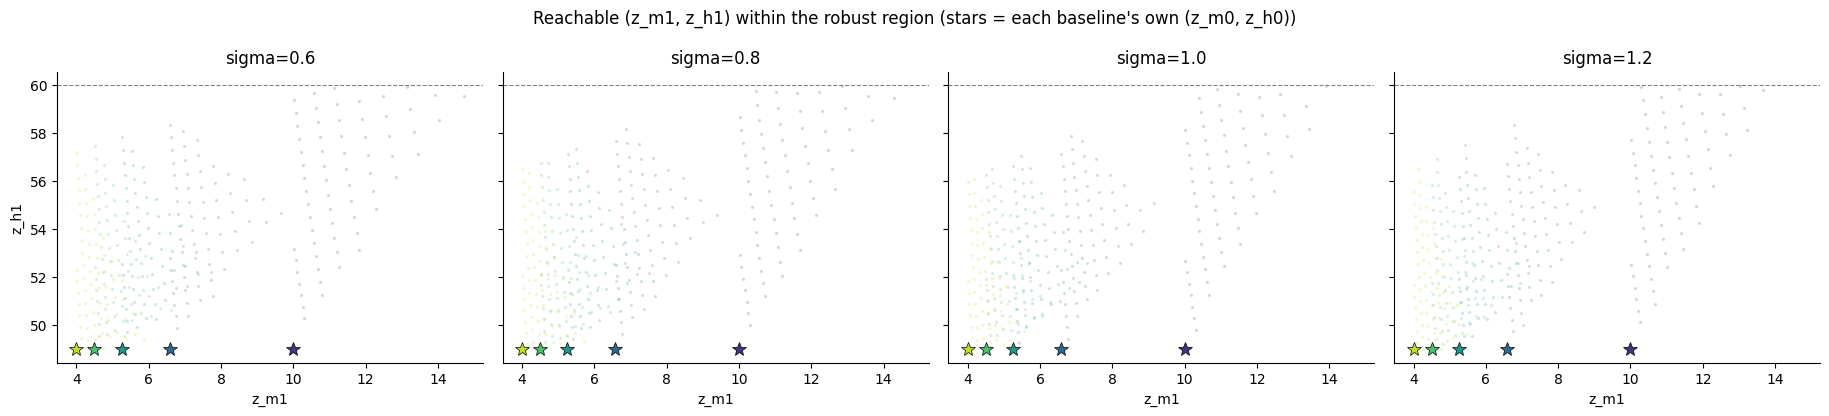

In [10]:
fig0d, axes0d = plt.subplots(
    1, len(INTERSECTION_SIGMA_SLICES), figsize=(4.6 * len(INTERSECTION_SIGMA_SLICES), 4.2), sharex=True, sharey=True,
)

for ax, sig in zip(axes0d, INTERSECTION_SIGMA_SLICES):
    points = baseline_band_points(sig)
    masks = [intervention_plausible_mask(a0, log_g0, sig, A1S, G1S, Z_H_RANGE[1]) for a0, log_g0 in points]
    intersection = np.logical_and.reduce(masks)
    colors = cmap(np.linspace(0.15, 0.9, len(points)))

    for (a0, log_g0), color in zip(points, colors):
        g0 = 10.0 ** log_g0
        z_m0, z_h0 = sig / np.sqrt(a0), a0 / g0
        if intersection.any():
            A1_in, G1_in = a0 * A1S[intersection], g0 ** G1S[intersection]
            ax.scatter(sig / np.sqrt(A1_in), A1_in / G1_in, s=2, color=color, alpha=0.15)
        ax.plot(z_m0, z_h0, "*", color=color, ms=10, mec="black", mew=0.5)

    ax.axhline(Z_H_RANGE[1], color="gray", lw=0.8, ls="--")
    ax.set_title(f"sigma={sig}")
    ax.set_xlabel("z_m1")

axes0d[0].set_ylabel("z_h1")
fig0d.suptitle("Reachable (z_m1, z_h1) within the robust region (stars = each baseline's own (z_m0, z_h0))")
plt.tight_layout()
plt.show()

### How does the actual fit loss behave across the plausible region?

Everything above only asked "is this combination biologically plausible" --
it never looked at the data. Before deciding *how* to constrain the
optimizer, it's worth seeing how the real loss (the same MLE objective,
`_weighted_neg_log_lik`, that `fit_single_phase`/`fit_two_phase_scale`
minimize in this file) actually varies across the plausible region: is it roughly flat (any
plausible point is about as good, so a hard constraint costs ~nothing), or
does it have a clear gradient pointing toward -- or worse, out of -- the
plausible region (meaning the unconstrained optimum really does want to
leave, and a hard constraint is doing real work, not just tidying up)?

`loss_grid_baseline` below evaluates the exact same objective as
`fit_single_phase`'s `build_objective`, at every grid point directly (no
optimizer, common random numbers per `sigma` slice so the surface is
smooth), restricted to each `sigma`'s plausible `(a0, log_g0)` band plus a
small margin outside it for context -- the margin is what shows whether
the loss keeps improving right up to, and past, the plausible boundary.

Swept across `SIGMA_LOSS_SWEEP` (10 slices, 2 rows of 5 by default) rather
than just a few spot-checked values, so the sweep covers wherever Step 1's
actual constrained fit ends up landing, not just a handful of arbitrary
points.

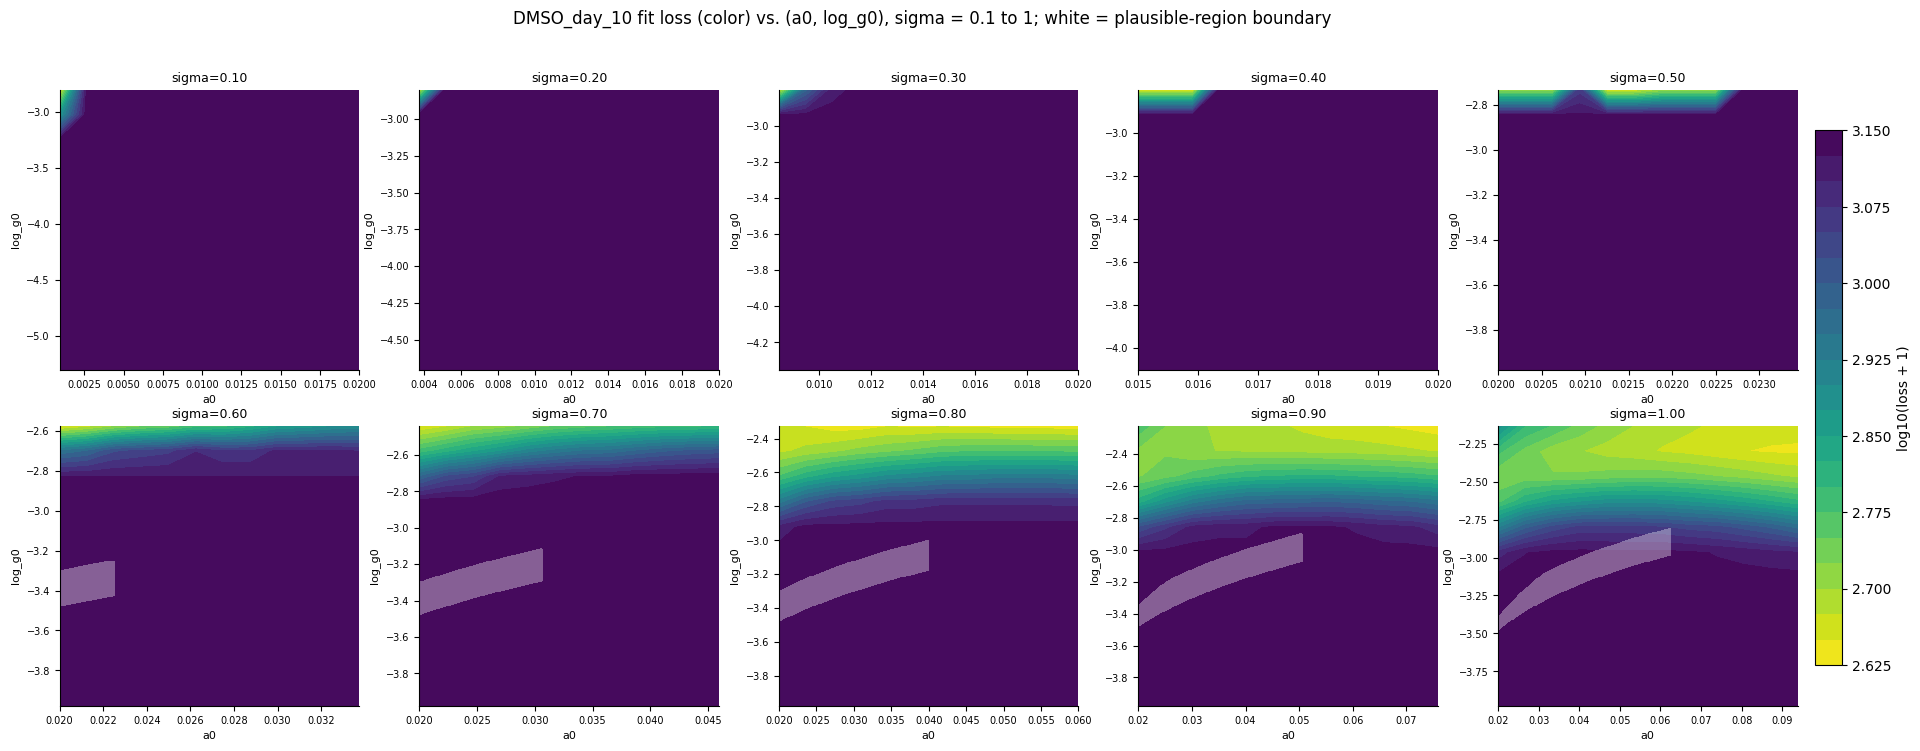

In [11]:
def loss_grid_baseline(cond, a_vals, log_g_vals, sigma, dt=0.1, n_paths=800, seed=0):
    noise = _make_common_noise(n_paths, dt, cond["t_max"], seed=seed)
    loss = np.full((len(log_g_vals), len(a_vals)), np.nan)
    for i, log_g in enumerate(log_g_vals):
        for j, a in enumerate(a_vals):
            g = 10.0 ** log_g
            z_h = a / g
            try:
                T, _, _ = simulate_fpt_and_state(
                    n_paths, a, g, sigma ** 2, z_h, z0=0.0, dt=dt, t_max=cond["t_max"], noise=noise,
                )
                loss[i, j] = _weighted_neg_log_lik(T, cond, n_paths)
            except (FloatingPointError, ValueError):
                loss[i, j] = np.nan
    return loss


def dmso_axis_ranges(sig):
    """(a_range, log_g_range) covered by the DMSO loss landscape at one
    sigma -- shared by both the coarse loss grid and the fine plausibility
    boundary below, so the two always agree on what region is being shown."""
    a_lo, a_hi = a_bounds_from_zm(sig, Z_M_RANGE)
    a_range = (max(a_lo * 0.5, 0.02), a_hi * 1.5)
    a_probe = np.linspace(*a_range, N_LOSS_GRID)
    log_g_lo = min(log_g_bounds_from_a_zh(a, Z_H_RANGE)[0] for a in a_probe) - LOSS_MARGIN
    log_g_hi = max(log_g_bounds_from_a_zh(a, Z_H_RANGE)[1] for a in a_probe) + LOSS_MARGIN
    return a_range, (log_g_lo, log_g_hi)


def dmso_loss_grid_at_sigma(sig):
    """(A_L, LOG_G_L, loss) for the DMSO loss landscape at one sigma --
    factored out so both the sweep plot and Step 1's own-fit plot can share
    it. Deliberately does *not* also return a plausibility mask on this same
    coarse grid -- see fine_baseline_boundary below for why."""
    a_range, log_g_range = dmso_axis_ranges(sig)
    a_vals = np.linspace(*a_range, N_LOSS_GRID)
    log_g_vals = np.linspace(*log_g_range, N_LOSS_GRID)
    loss = loss_grid_baseline(dmso_curve, a_vals, log_g_vals, sig, seed=int(round(sig * 1000)))
    A_L, LOG_G_L = np.meshgrid(a_vals, log_g_vals)
    return A_L, LOG_G_L, loss


def fine_baseline_boundary(sig, a_range, log_g_range, n=N_BOUNDARY_GRID):
    """Fine-resolution counterpart to dmso_loss_grid_at_sigma's coarse grid,
    analogous to fine_intervention_boundary: the (a0, log_g0) plausibility
    check is pure algebra (no simulation), so it's cheap to trace at much
    higher resolution than N_LOSS_GRID. Tracing the boundary on the *same*
    coarse grid as the (expensive) loss heatmap -- the original approach --
    visibly kinks/cuts corners once the plausible band gets narrow (e.g.
    tightening Z_H_RANGE), which can make a genuinely plausible point (by
    the exact algebraic check) appear to sit just outside the drawn white
    contour. This is the same failure mode already fixed for the
    intervention plots; this is the missing baseline-plot counterpart."""
    a_fine = np.linspace(*a_range, n)
    log_g_fine = np.linspace(*log_g_range, n)
    A_FINE, LOG_G_FINE = np.meshgrid(a_fine, log_g_fine)
    G_FINE = 10.0 ** LOG_G_FINE
    Z_M_FINE, Z_H_FINE = sig / np.sqrt(A_FINE), A_FINE / G_FINE
    GAMMA_FINE = A_FINE * Z_H_FINE ** 2 / sig ** 2
    mask = (
        (Z_M_FINE >= Z_M_RANGE[0]) & (Z_M_FINE <= Z_M_RANGE[1])
        & (Z_H_FINE >= Z_H_RANGE[0]) & (Z_H_FINE <= Z_H_RANGE[1]) & (GAMMA_FINE >= GAMMA_MIN)
    )
    return A_FINE, LOG_G_FINE, mask


def draw_plausible_region(ax, A, G, mask):
    """
    Shade the plausible region with a single translucent `contourf` fill
    (alpha=0.35), rather than an outline-only `contour(levels=[0.5])` --
    used for the `(a0, log_g0)` plots, where the plausible region is
    normally many grid cells wide, so `contourf`'s polygons render fine.

    (The `(a1_scale, g1_scale)` plots use `draw_intervention_region`
    instead, an exact analytic pair of boundary curves -- that region *can*
    narrow to a sliver only 1 grid cell wide, e.g. whenever a baseline's own
    `z_h0` lands close to `Z_H_RANGE`'s ceiling, where a grid-based fill or
    outline would show visible gaps/dots regardless of resolution. Stacking
    many overlapping semi-transparent scatter markers was tried here as a
    fallback for that case, but backfires for the normal, many-cells-wide
    case this function handles: hundreds of overlapping alpha=0.7 markers
    compound to near-total opacity, hiding the loss heatmap underneath --
    which is why that's not done here.)
    """
    if not mask.any():
        return
    ax.contourf(A, G, mask, levels=[0.5, 1.5], colors=["white"], alpha=0.35)


def intervention_boundary_curves(a0, log_g0, z_h_max, a1_range, n=300):
    """
    Exact closed-form counterpart to fine_intervention_boundary, for the
    `(a1_scale, g1_scale)` plots specifically: solving `z_h1 = a0*a1_scale /
    g0**g1_scale` for `g1_scale` at a fixed target `z_h1` gives `g1_scale`
    directly as a smooth function of `a1_scale`, i.e. the plausible region's
    two `z_h1` edges (`z_h1=z_h0` and `z_h1=z_h_max`) are just two curves,
    not something that needs a grid/mask at all. This matters because that
    region can become extremely thin (a sliver, whenever the baseline's own
    `z_h0` sits close to `z_h_max`) -- at any finite grid resolution a thin
    sliver traced via `intervention_plausible_mask` only touches a handful
    of grid cells, so `contour`/`contourf`/even a scatter of grid points all
    show visible gaps; the analytic curves have no such resolution limit
    and stay exact and gap-free no matter how thin the true region is.

    Returns (a1_vals, g1_lo, g1_hi) for ax.fill_between -- NaN past
    `a1_scale > 1` (where `z_m1 >= z_m0` can never hold, see
    is_plausible_intervention).
    """
    g0 = 10.0 ** log_g0
    z_h0 = a0 / g0
    a1_vals = np.linspace(a1_range[0], a1_range[1], n)
    with np.errstate(all="ignore"):
        g1_lo = np.log10(a0 * a1_vals / z_h0) / np.log10(g0)
        g1_hi = np.log10(a0 * a1_vals / z_h_max) / np.log10(g0)
    beyond = a1_vals > 1.0
    g1_lo[beyond] = np.nan
    g1_hi[beyond] = np.nan
    return a1_vals, g1_lo, g1_hi


def draw_intervention_region(ax, a0, log_g0, z_h_max, a1_range):
    """Shade + outline the exact (a1_scale, g1_scale) plausible band via
    intervention_boundary_curves -- see that function's docstring for why
    this replaces the grid-based draw_plausible_region here specifically."""
    a1_vals, g1_lo, g1_hi = intervention_boundary_curves(a0, log_g0, z_h_max, a1_range)
    ax.fill_between(a1_vals, g1_lo, g1_hi, color="white", alpha=0.35, zorder=2)
    ax.plot(a1_vals, g1_lo, color="white", lw=1.4, zorder=3)
    ax.plot(a1_vals, g1_hi, color="white", lw=1.4, zorder=3)


fig0e, axes0e = plt.subplots(2, 5, figsize=(4.6 * 5, 4.0 * 2), sharey=False)
for ax, sig in zip(axes0e.ravel(), SIGMA_LOSS_SWEEP):
    A_L, LOG_G_L, loss = dmso_loss_grid_at_sigma(sig)
    a_range, log_g_range = dmso_axis_ranges(sig)
    A_B, LOG_G_B, plausible_fine = fine_baseline_boundary(sig, a_range, log_g_range)
    cf = ax.contourf(A_L, LOG_G_L, np.log10(loss + 1.0), levels=20, cmap="viridis_r")
    draw_plausible_region(ax, A_B, LOG_G_B, plausible_fine)
    ax.set_title(f"sigma={sig:.2f}", fontsize=9)
    ax.set_xlabel("a0", fontsize=8)
    ax.set_ylabel("log_g0", fontsize=8)
    ax.tick_params(labelsize=7)
fig0e.colorbar(cf, ax=axes0e, fraction=0.015, pad=0.01, label="log10(loss + 1)")
fig0e.suptitle(f"DMSO_day_10 fit loss (color) vs. (a0, log_g0), sigma = "
               f"{SIGMA_LOSS_SWEEP[0]:.2g} to {SIGMA_LOSS_SWEEP[-1]:.2g}; white = plausible-region boundary")
plt.show()

Same idea for `Auxin_day_21`'s `(a1_scale, g1_scale)`. `loss_grid_intervention`/
`auxin21_loss_landscape` below are defined here but only actually plotted
once Step 2 has a real fitted baseline to evaluate them at (see that
section's own "Where does this fit actually land on the loss landscape?"
plot) -- there's no useful baseline to illustrate this against yet.

In [12]:
def loss_grid_intervention(a0, log_g0, sigma, t_switch, cond, a1_vals, g1_vals, dt=0.1, n_paths=800, seed=0):
    g0 = 10.0 ** log_g0
    z_h0 = a0 / g0
    noise1 = _make_common_noise(n_paths, dt, t_switch, seed=seed)
    noise2 = _make_common_noise(n_paths, dt, cond["t_max"] - t_switch, seed=seed + 1)
    loss = np.full((len(g1_vals), len(a1_vals)), np.nan)
    for i, g1_scale in enumerate(g1_vals):
        for j, a1_scale in enumerate(a1_vals):
            a1, g1 = a0 * a1_scale, g0 ** g1_scale
            z_h1 = a1 / g1
            try:
                T = simulate_two_phase(
                    n_paths, a0, z_h0, a1, z_h1, sigma ** 2, t_switch, cond["t_max"], dt,
                    noise1=noise1, noise2=noise2,
                )
                loss[i, j] = _weighted_neg_log_lik(T, cond, n_paths)
            except (FloatingPointError, ValueError):
                loss[i, j] = np.nan
    return loss


def fine_intervention_boundary(a0, log_g0, sigma, a1_range, g1_range, z_h_max, n=N_BOUNDARY_GRID):
    """The plausibility boundary is pure algebra (intervention_plausible_mask),
    so it's cheap to trace at much finer resolution than the loss heatmap
    (which needs an actual simulation per grid point) -- doing so avoids the
    broken/fragmented contour a boundary this curved can produce when traced
    on the same coarse N_LOSS_GRID used for the (expensive) loss surface."""
    a1_fine = np.linspace(*a1_range, n)
    g1_fine = np.linspace(*g1_range, n)
    A1_FINE, G1_FINE = np.meshgrid(a1_fine, g1_fine)
    return A1_FINE, G1_FINE, intervention_plausible_mask(a0, log_g0, sigma, A1_FINE, G1_FINE, z_h_max)


def tight_intervention_box(a0, log_g0, sigma, z_h_max, a1_scale_outer, g1_scale_outer,
                            n=N_BOUNDARY_GRID, pad_frac=0.05):
    """
    Numeric counterpart to `tight_baseline_box` for `(a1_scale, g1_scale)`:
    there's no equally clean closed form here (the two scale factors enter
    `z_h1` multiplicatively, `z_h1 = a0*a1_scale / g0**g1_scale`), but the
    plausibility check itself is still pure algebra -- so evaluate it on a
    fine grid over the outer envelope (`fine_intervention_boundary`, cheap)
    and take *that* mask's own bounding box, padded a little, as the tight
    search box. This is what actually prevents the narrow-bounds failure
    mode for Step 2: without it, `differential_evolution`'s population is
    sampled across the full (often much larger) outer envelope and can
    easily miss a thin plausible sliver entirely -- see this notebook's
    `tight_baseline_box` docstring for the same failure mode in Step 1.

    Falls back to the outer envelope unchanged if the grid finds no
    plausible point at all (still safer than handing the optimizer a box
    that's `nan`/inverted); the finite-loss check in `fit_two_phase_scale`
    is the last-resort safety net if that happens.
    """
    A1_FINE, G1_FINE, mask = fine_intervention_boundary(a0, log_g0, sigma, a1_scale_outer, g1_scale_outer, z_h_max, n=n)
    if not mask.any():
        return a1_scale_outer, g1_scale_outer
    a1_lo, a1_hi = A1_FINE[mask].min(), A1_FINE[mask].max()
    g1_lo, g1_hi = G1_FINE[mask].min(), G1_FINE[mask].max()
    pad_a1 = pad_frac * max(a1_hi - a1_lo, 1e-6)
    pad_g1 = pad_frac * max(g1_hi - g1_lo, 1e-6)
    return (
        (max(a1_scale_outer[0], a1_lo - pad_a1), min(a1_scale_outer[1], a1_hi + pad_a1)),
        (max(g1_scale_outer[0], g1_lo - pad_g1), min(g1_scale_outer[1], g1_hi + pad_g1)),
    )


def auxin21_loss_landscape(a0, log_g0, sigma, seed):
    """(A1_L, G1_L, loss, A1_B, G1_B, mask_fine) for the Auxin_day_21 loss
    landscape at one baseline -- factored out so both the reference-point
    plot and Step 2's own-fit plot can share it."""
    a1_vals = np.linspace(*A1_SCALE_LOSS_RANGE, N_LOSS_GRID)
    g1_vals = np.linspace(*G1_SCALE_LOSS_RANGE, N_LOSS_GRID)
    loss = loss_grid_intervention(a0, log_g0, sigma, T_SWITCH_21, auxin21_curve, a1_vals, g1_vals, seed=seed)
    A1_L, G1_L = np.meshgrid(a1_vals, g1_vals)
    A1_B, G1_B, mask_fine = fine_intervention_boundary(
        a0, log_g0, sigma, A1_SCALE_LOSS_RANGE, G1_SCALE_LOSS_RANGE, Z_H_RANGE[1],
    )
    return A1_L, G1_L, loss, A1_B, G1_B, mask_fine

### Boundary-hugging diagnostic

A fitted value sitting within 2% of its bound means the *box*, not the
data, decided that parameter -- the optimizer wanted to keep going but was
stopped. This is expected here and there (see the identifiability caveat
above), but should never pass silently: `_fmt` below flags it explicitly
next to every reported value.

In [13]:
def _fmt(name, value, bounds):
    lo, hi = bounds
    tol = 0.02 * (hi - lo)
    flag = ""
    if value - lo < tol:
        flag = "  <-- AT LOWER BOUND, widen it"
    elif hi - value < tol:
        flag = "  <-- AT UPPER BOUND, widen it"
    print(f"  {name:<15} = {value:.4f}   [bounds {bounds}]{flag}")

## Step 1 -- `(a0, log_g0, sigma)` from `DMSO_day_10` alone

`is_plausible_baseline` (Step 0) is passed in as a **hard constraint**
(`plausible_fn`): any `(a, log_g, sigma)` outside the biologically
plausible region is rejected outright, before its simulated loss is even
computed, regardless of whether it happens to fit `S(t)` better than
anything inside the plausible region does. That's the actual fix for the
earlier `z_h=321,772` result.

The search itself runs in `tight_baseline_box(Z_M_RANGE, Z_H_RANGE,
sigma_bounds=SIGMA_BOUNDS)` -- **not** the raw `A_BOUNDS`/`LOG_G_BOUNDS`
from the Configuration cell -- since those are only meant as a generic
outer sanity cap, and can be far larger than the true plausible region
once `Z_M_RANGE`/`Z_H_RANGE` are narrowed (see `tight_baseline_box`'s
docstring): searching a box much bigger than the plausible region risks
the optimizer's population missing it entirely and returning a
meaningless `loss=inf` result. `fit_single_phase` now raises a clear
error if that happens anyway, rather than silently returning garbage.

In [14]:
A_BOUNDS_TIGHT, LOG_G_BOUNDS_TIGHT = tight_baseline_box(Z_M_RANGE, Z_H_RANGE, sigma_bounds=SIGMA_BOUNDS)
print(f"Step 1 search box: a0 in {tuple(round(x, 4) for x in A_BOUNDS_TIGHT)}, "
      f"log_g0 in {tuple(round(x, 4) for x in LOG_G_BOUNDS_TIGHT)}  "
      f"(outer envelope was a0 in {A_BOUNDS}, log_g0 in {LOG_G_BOUNDS})")

fit_dmso = fit_single_phase(
    dmso_curve, A_BOUNDS_TIGHT, LOG_G_BOUNDS_TIGHT, sigma_bounds=SIGMA_BOUNDS, seed=42,
    plausible_fn=is_plausible_baseline,
)
a0, log_g0, sigma = fit_dmso["a"], fit_dmso["log_g"], fit_dmso["sigma"]

print(f"DMSO_day_10 (n={dmso_curve['n_total']} worms), constrained to the plausible region:")
_fmt("a0", a0, A_BOUNDS_TIGHT)
_fmt("log_g0", log_g0, LOG_G_BOUNDS_TIGHT)
_fmt("sigma", sigma, SIGMA_BOUNDS)
print(f"  z_m0={sigma / np.sqrt(a0):.2f}  z_h0={a0 / (10.0 ** log_g0):.2f}  "
      f"plausible={is_plausible_baseline(a0, log_g0, sigma)}")
print(f"  loss   = {fit_dmso['loss']:.4f}")

Step 1 search box: a0 in (0.0004, 0.25), log_g0 in (np.float64(-5.1761), np.float64(-2.2041))  (outer envelope was a0 in (0.02, 1.0), log_g0 in (-5.0, -0.5))


DMSO_day_10 (n=232 worms), constrained to the plausible region:
  a0              = 0.1553   [bounds (0.0004, 0.25)]
  log_g0          = -2.5439   [bounds (np.float64(-5.176091259055681), np.float64(-2.2041199826559246))]
  sigma           = 1.5941   [bounds (0.2, 2.0)]
  z_m0=4.05  z_h0=54.34  plausible=True
  loss   = 398.9054


### Where does this fit actually land on the loss landscape?

Same construction as the `sigma`-sweep above (`dmso_loss_grid_at_sigma`,
white = plausible-region boundary), but evaluated at Step 1's *own* fitted
`sigma` exactly (not the nearest slice from that sweep) and with the
optimizer's chosen `(a0, log_g0)` marked directly -- the fastest way to
confirm the fit landed inside the plausible region on the loss surface's
own visible minimum there, rather than merely "somewhere plausible."

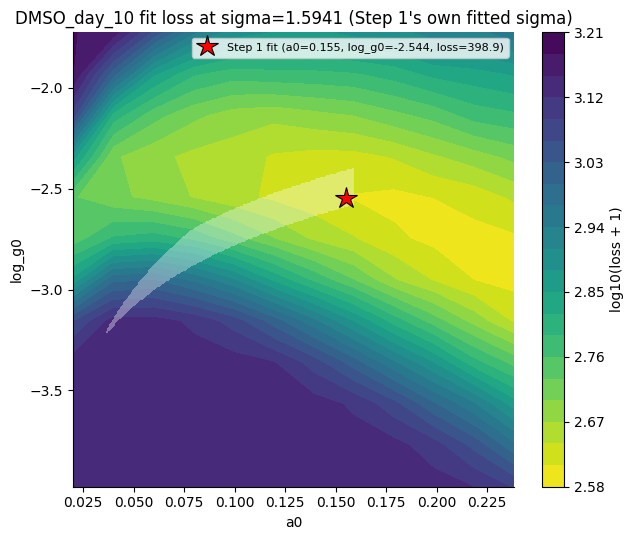

In [15]:
A_FIT, LOG_G_FIT, loss_fit = dmso_loss_grid_at_sigma(sigma)
a_range_fit, log_g_range_fit = dmso_axis_ranges(sigma)
A_FIT_B, LOG_G_FIT_B, plausible_fit = fine_baseline_boundary(sigma, a_range_fit, log_g_range_fit)

fig1a, ax1a = plt.subplots(figsize=(6.5, 5.5))
cf1a = ax1a.contourf(A_FIT, LOG_G_FIT, np.log10(loss_fit + 1.0), levels=20, cmap="viridis_r")
draw_plausible_region(ax1a, A_FIT_B, LOG_G_FIT_B, plausible_fit)
ax1a.plot(a0, log_g0, "r*", ms=16, mec="black", mew=0.8,
          label=f"Step 1 fit (a0={a0:.3f}, log_g0={log_g0:.3f}, loss={fit_dmso['loss']:.1f})")
ax1a.set_xlabel("a0")
ax1a.set_ylabel("log_g0")
ax1a.set_title(f"DMSO_day_10 fit loss at sigma={sigma:.4f} (Step 1's own fitted sigma)")
ax1a.legend(fontsize=8, loc="upper right")
fig1a.colorbar(cf1a, ax=ax1a, label="log10(loss + 1)")
plt.tight_layout()
plt.show()

### How does `R = z_h/z_m` affect death-time variability?

The three dynamical regimes -- noise-dominated (`z < z_m`), exponential
(`z_m < z < z_h`), hyperbolic/absorbing (`z > z_h`) -- mean `R = z_h/z_m`
is literally "how many e-folds of self-reinforcing exponential growth
happen before the wall" (`ln(R)` e-folds). That has a direct, checkable
consequence: a longer, more deterministic exponential phase (`R` large)
pins down the crossing time more tightly, so simulated deaths cluster more
tightly around the mean -- i.e. the coefficient of variation (CV = std /
mean) of death times should *decrease* as `R` increases. Too small an `R`
gives almost pure noise-driven escape (high CV, closer to memoryless);
too large synchronizes deaths well beyond what real cohorts show.

This sweeps `R` (holding `a0`, `sigma` fixed at Step 1's own fit, varying
only `z_h`) and compares each simulated CV against `DMSO_day_10`'s own
empirical CV (weighted mean/std of its *observed*, uncensored death ages)
-- the real answer to "how much room should the exponential regime get,"
rather than intuition alone.

DMSO_day_10 empirical (n=204 of 232 worms observed to die, rest censored): mean age=19.47, std=3.43, CV=0.176


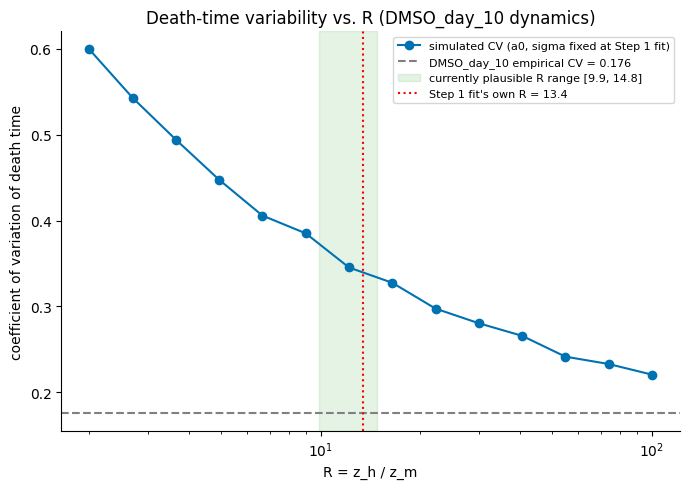

In [16]:
def weighted_cv_from_grouped(data):
    """Weighted mean/std/CV of *observed* (uncensored) death times from a
    data.GroupedSurvivalData -- censored worms only tell us they were
    still alive at removal, not their actual death age, so including them
    would bias the spread estimate."""
    died = data.event_observed == 1
    t, w = data.t[died], data.weight[died]
    mean = np.average(t, weights=w)
    var = np.average((t - mean) ** 2, weights=w)
    return mean, np.sqrt(var), np.sqrt(var) / mean


dmso_mean_emp, dmso_std_emp, dmso_cv_emp = weighted_cv_from_grouped(raw_data["DMSO_day_10"])
_dmso_data = raw_data["DMSO_day_10"]
_n_died = int(_dmso_data.weight[_dmso_data.event_observed == 1].sum())
print(f"DMSO_day_10 empirical (n={_n_died} of {_dmso_data.n_total} worms observed to die, "
      f"rest censored): mean age={dmso_mean_emp:.2f}, std={dmso_std_emp:.2f}, CV={dmso_cv_emp:.3f}")

N_CV_SWEEP = 3000
DT_CV = 0.1
T_MAX_CV = 300.0   # generous runway so every path actually dies, even at large R -- not dmso_curve["t_max"]

z_m0_here = sigma / np.sqrt(a0)
R_plausible_lo, R_plausible_hi = Z_H_RANGE[0] / z_m0_here, Z_H_RANGE[1] / z_m0_here
R_current = (a0 / (10.0 ** log_g0)) / z_m0_here
R_sweep = np.geomspace(2.0, max(R_plausible_hi * 1.5, 100.0), 14)

cv_sim = np.full(len(R_sweep), np.nan)
mean_sim = np.full(len(R_sweep), np.nan)
for i, R in enumerate(R_sweep):
    z_h_r = R * z_m0_here
    g_r = a0 / z_h_r
    T_r, _, _ = simulate_fpt_and_state(
        N_CV_SWEEP, a0, g_r, sigma ** 2, z_h_r, z0=0.0, dt=DT_CV, t_max=T_MAX_CV,
        rng=np.random.default_rng(1),
    )
    died_mask = T_r < T_MAX_CV
    if died_mask.sum() > 10:
        mean_sim[i] = T_r[died_mask].mean()
        cv_sim[i] = T_r[died_mask].std() / mean_sim[i]

fig1b, ax1b = plt.subplots(figsize=(7, 5))
ax1b.plot(R_sweep, cv_sim, "o-", color="#0072B2", label="simulated CV (a0, sigma fixed at Step 1 fit)")
ax1b.axhline(dmso_cv_emp, color="gray", ls="--", label=f"DMSO_day_10 empirical CV = {dmso_cv_emp:.3f}")
ax1b.axvspan(R_plausible_lo, R_plausible_hi, color="#4daf4a", alpha=0.15,
             label=f"currently plausible R range [{R_plausible_lo:.1f}, {R_plausible_hi:.1f}]")
ax1b.axvline(R_current, color="red", ls=":", label=f"Step 1 fit's own R = {R_current:.1f}")
ax1b.set_xscale("log")
ax1b.set_xlabel("R = z_h / z_m")
ax1b.set_ylabel("coefficient of variation of death time")
ax1b.set_title("Death-time variability vs. R (DMSO_day_10 dynamics)")
ax1b.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Deriving `Z_H_RANGE` (or `Z_M_RANGE`) from a target `R`

`z_h = R * z_m` is monotonic *increasing* in both `R` and `z_m` -- so if
`R` is constrained to `R_RANGE` and `z_m` to `Z_M_RANGE`, the achievable
`z_h` range's extremes sit exactly at the corners of that box:
`z_h_min = R_RANGE[0] * Z_M_RANGE[0]`, `z_h_max = R_RANGE[1] *
Z_M_RANGE[1]`. No grid search needed -- this is the "simple calculation"
version of what Step 0's `a_bounds_from_zm`/`log_g_bounds_from_a_zh`
compute per-point; `z_h_range_from_R` below is the same idea, just in
terms of `R` (diffusive fraction `1/R`) directly rather than the absolute
`Z_H_RANGE` used so far.

In [17]:
def z_h_range_from_R(z_m_range, R_range):
    return R_range[0] * z_m_range[0], R_range[1] * z_m_range[1]


# What R_RANGE is implied by the *currently configured* Z_M_RANGE/Z_H_RANGE?
R_range_current = (Z_H_RANGE[0] / Z_M_RANGE[1], Z_H_RANGE[1] / Z_M_RANGE[0])
print(f"Currently configured Z_M_RANGE={Z_M_RANGE}, Z_H_RANGE={Z_H_RANGE} "
      f"=> implied R in [{R_range_current[0]:.1f}, {R_range_current[1]:.1f}] "
      f"(diffusive fraction {1 / R_range_current[1]:.1%} to {1 / R_range_current[0]:.1%})")

# Example: the CV sweep above never quite reached the empirical CV even at
# R~140 -- what Z_H_RANGE would a target R_RANGE of, say, [20, 150] imply,
# keeping Z_M_RANGE as-is?
R_RANGE_EXAMPLE = (20.0, 150.0)
z_h_example = z_h_range_from_R(Z_M_RANGE, R_RANGE_EXAMPLE)
print(f"\nExample: target R_RANGE={R_RANGE_EXAMPLE} (diffusive fraction "
      f"{1 / R_RANGE_EXAMPLE[1]:.1%} to {1 / R_RANGE_EXAMPLE[0]:.1%}), "
      f"keeping Z_M_RANGE={Z_M_RANGE}:")
print(f"  => Z_H_RANGE should be ({z_h_example[0]:.1f}, {z_h_example[1]:.1f})  "
      f"(currently {Z_H_RANGE})")
print("  If you want this, copy the printed Z_H_RANGE (and/or R_RANGE_EXAMPLE) "
      "into the Configuration cell and Run All.")

Currently configured Z_M_RANGE=(4.0, 10.0), Z_H_RANGE=(40.0, 60.0) => implied R in [4.0, 15.0] (diffusive fraction 6.7% to 25.0%)

Example: target R_RANGE=(20.0, 150.0) (diffusive fraction 0.7% to 5.0%), keeping Z_M_RANGE=(4.0, 10.0):
  => Z_H_RANGE should be (80.0, 1500.0)  (currently (40.0, 60.0))
  If you want this, copy the printed Z_H_RANGE (and/or R_RANGE_EXAMPLE) into the Configuration cell and Run All.


## Step 1b -- `Auxin_day_10`'s own `(a0_auxin10, log_g0_auxin10)`

Independent single-phase fit, `sigma` fixed at Step 1's value, `(a, log_g)`
free -- **not** expressed via `g1_scale`/`a1_scale` and **not** anchored to
DMSO's dynamics at all, since these worms were under auxin from day 0. Same
hard constraint as Step 1, and same tight-box treatment (`sigma` is fixed
here, so `tight_baseline_box` uses its `sigma_fixed=` path).

In [18]:
A_BOUNDS_AUXIN10, LOG_G_BOUNDS_AUXIN10 = tight_baseline_box(Z_M_RANGE, Z_H_RANGE, sigma_fixed=sigma)

fit_auxin10 = fit_single_phase(
    auxin10_curve, A_BOUNDS_AUXIN10, LOG_G_BOUNDS_AUXIN10, sigma_fixed=sigma, seed=43,
    plausible_fn=is_plausible_baseline,
)
a0_auxin10, log_g0_auxin10 = fit_auxin10["a"], fit_auxin10["log_g"]

print(f"Auxin_day_10 (n={auxin10_curve['n_total']} worms), sigma fixed at {sigma:.4f}, constrained:")
_fmt("a0_auxin10", a0_auxin10, A_BOUNDS_AUXIN10)
_fmt("log_g0_auxin10", log_g0_auxin10, LOG_G_BOUNDS_AUXIN10)
print(f"  loss = {fit_auxin10['loss']:.4f}")

Auxin_day_10 (n=81 worms), sigma fixed at 1.5941, constrained:
  a0_auxin10      = 0.1035   [bounds (np.float64(0.025412186510295722), np.float64(0.15882616568934824))]
  log_g0_auxin10  = -2.7358   [bounds (np.float64(-3.3731092162461946), np.float64(-2.4011379398464383))]
  loss = 186.9954


## Step 2 -- `(g1_scale, a1_scale)` from `Auxin_day_21` only

The only condition actually modeled as a DMSO worm up to a switch day.
`sigma` fixed at Step 1's value; phase 1 fixed at Step 1's `(a0, log_g0)`.
`is_plausible_intervention` (partially applied to this run's own fitted
`(a0, log_g0, sigma)`, so it's checked against the actual baseline being
used here, not the reference point) is passed in as `plausible_fn` -- both
barriers moving up and `z_h1` staying under the outer limit are hard
requirements, not preferences.

This baseline's own `z_h0` sets a hard ceiling on how much room is even
possible: `z_h1` must land in `[z_h0, Z_H_RANGE[1]]`, so if `z_h0` happens
to land close to `Z_H_RANGE[1]` (which Step 1 has no reason to avoid --
it only knows about the *baseline* plausibility range, not this
downstream constraint), that window can shrink to almost nothing. Printed
explicitly below so a thin window is visible *before* the fit, not
discovered as a mysterious `loss=inf` after. As in Step 1, the search
itself runs in `tight_intervention_box` (numeric version of
`tight_baseline_box`) rather than the raw `A1_SCALE_BOUNDS`/
`G1_SCALE_BOUNDS` outer envelope, for the same reason.

In [19]:
z_h0_current = a0 / (10.0 ** log_g0)
window_width = Z_H_RANGE[1] - z_h0_current
print(f"Post-switch z_h1 window: [{z_h0_current:.2f}, {Z_H_RANGE[1]:.2f}]  (width={window_width:.2f})")
if window_width <= 0:
    print("  WARNING: zero/negative width -- z_h0 already at or past Z_H_RANGE's ceiling, "
          "so NO (a1_scale, g1_scale) can be plausible. Widen Z_H_RANGE, or tighten "
          "Z_M_RANGE/Z_H_RANGE so Step 1's z_h0 lands further from the ceiling.")
elif window_width < 0.1 * Z_H_RANGE[1]:
    print(f"  WARNING: window is only {window_width / Z_H_RANGE[1]:.1%} of Z_H_RANGE's span -- "
          "the fit below may still work (tight_intervention_box searches this exact "
          "region directly) but there's very little headroom; consider widening Z_H_RANGE.")


def _plausible_intervention_here(a1_scale, g1_scale):
    return is_plausible_intervention(a1_scale, g1_scale, a0, log_g0, sigma, Z_H_RANGE[1])


A1_SCALE_BOUNDS_TIGHT, G1_SCALE_BOUNDS_TIGHT = tight_intervention_box(
    a0, log_g0, sigma, Z_H_RANGE[1], A1_SCALE_BOUNDS, G1_SCALE_BOUNDS,
)
print(f"Step 2 search box: a1_scale in {tuple(round(x, 4) for x in A1_SCALE_BOUNDS_TIGHT)}, "
      f"g1_scale in {tuple(round(x, 4) for x in G1_SCALE_BOUNDS_TIGHT)}  "
      f"(outer envelope was a1_scale in {A1_SCALE_BOUNDS}, g1_scale in {G1_SCALE_BOUNDS})")

fit_auxin21 = fit_two_phase_scale(
    a0, log_g0, sigma, T_SWITCH_21, auxin21_curve,
    A1_SCALE_BOUNDS_TIGHT, G1_SCALE_BOUNDS_TIGHT, seed=44,
    plausible_fn=_plausible_intervention_here,
)
a1_scale, g1_scale = fit_auxin21["a1_scale"], fit_auxin21["g1_scale"]

print(f"Auxin_day_21 (n={auxin21_curve['n_total']} worms), sigma fixed at {sigma:.4f}, "
      f"phase 1 = DMSO (a0={a0:.4f}, log_g0={log_g0:.4f}), constrained:")
_fmt("a1_scale", a1_scale, A1_SCALE_BOUNDS_TIGHT)
_fmt("g1_scale", g1_scale, G1_SCALE_BOUNDS_TIGHT)
print(f"  -> a1 (alpha_auxin21)     = {fit_auxin21['a1']:.4f}")
print(f"  -> g1 (g_auxin21)         = {fit_auxin21['g1']:.4e}")
print(f"  loss = {fit_auxin21['loss']:.4f}")

Post-switch z_h1 window: [54.34, 60.00]  (width=5.66)
Step 2 search box: a1_scale in (0.1, np.float64(1.0439)), g1_scale in (np.float64(0.987), np.float64(1.4284))  (outer envelope was a1_scale in (0.1, 2.5), g1_scale in (0.1, 2.5))


Auxin_day_21 (n=247 worms), sigma fixed at 1.5941, phase 1 = DMSO (a0=0.1553, log_g0=-2.5439), constrained:
  a1_scale        = 0.8017   [bounds (0.1, np.float64(1.0439464882943144))]
  g1_scale        = 1.0510   [bounds (np.float64(0.9869565217391303), np.float64(1.428428093645485))]
  -> a1 (alpha_auxin21)     = 0.1245
  -> g1 (g_auxin21)         = 2.1201e-03
  loss = 462.5950


### Where does this fit actually land on the loss landscape?

Same idea as Step 1's version above, now for the `DMSO_day_10 ->
Auxin_day_21` switch: `auxin21_loss_landscape` evaluated at *this run's
own* fitted baseline `(a0, log_g0, sigma)` from Step 1, with Step 2's
chosen `(a1_scale, g1_scale)` marked directly.

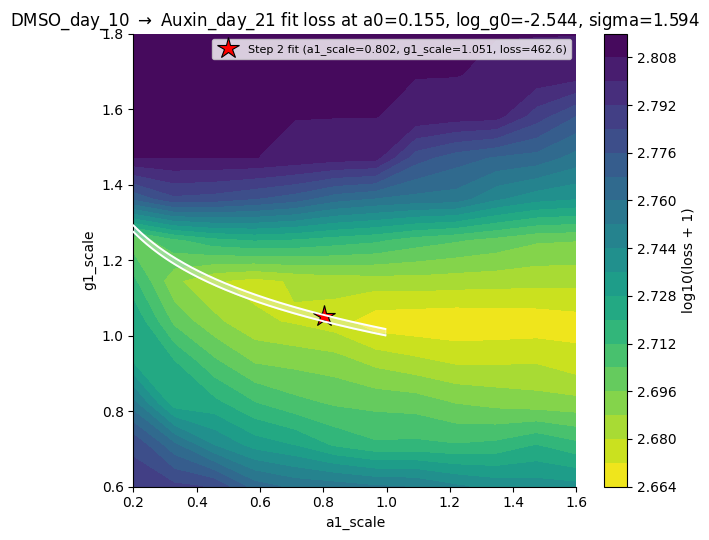

In [20]:
A1_FIT, G1_FIT, loss21_fit, A1_FIT_B, G1_FIT_B, mask21_fit_fine = auxin21_loss_landscape(a0, log_g0, sigma, seed=99)

fig2a, ax2a = plt.subplots(figsize=(6.5, 5.5))
cf2a = ax2a.contourf(A1_FIT, G1_FIT, np.log10(loss21_fit + 1.0), levels=20, cmap="viridis_r")
draw_intervention_region(ax2a, a0, log_g0, Z_H_RANGE[1], A1_SCALE_LOSS_RANGE)
ax2a.plot(a1_scale, g1_scale, "r*", ms=16, mec="black", mew=0.8,
          label=f"Step 2 fit (a1_scale={a1_scale:.3f}, g1_scale={g1_scale:.3f}, loss={fit_auxin21['loss']:.1f})")
ax2a.set_xlabel("a1_scale")
ax2a.set_ylabel("g1_scale")
ax2a.set_title(f"DMSO_day_10 $\\to$ Auxin_day_21 fit loss at a0={a0:.3f}, log_g0={log_g0:.3f}, sigma={sigma:.3f}")
ax2a.legend(fontsize=8, loc="upper right")
fig2a.colorbar(cf2a, ax=ax2a, label="log10(loss + 1)")
plt.tight_layout()
plt.show()

### Is the flat `loss21_fit` region actually degenerate in `(z_m1, z_h1)`?

The loss landscape above is visibly flat along a ridge/valley -- many
`(a1_scale, g1_scale)` pairs give near-identical loss. That alone doesn't
tell us whether those pairs describe the *same* underlying dynamics or
genuinely different ones: `a1 = a0*a1_scale` and `g1 = g0**g1_scale` both
move `z_h1 = a1/g1` and `z_m1 = sigma/sqrt(a1)`, so two points with equal
loss could still land on very different `(z_m1, z_h1)`, or the near-flat
region could be almost entirely one iso-`z_h1`/iso-`z_m1` contour (i.e.
the fit only actually constrains `z_h1`/`z_m1`, not `a1`/`g1` separately).
`loss21_fit`'s own grid (`N_LOSS_GRID`={N_LOSS_GRID} per axis, spanning the
*entire* outer `A1_SCALE_LOSS_RANGE`/`G1_SCALE_LOSS_RANGE`) is far too
coarse for this: the printed "Step 2 search box" above shows the actual
plausible sliver is razor-thin (z_h1 window width was only a few percent
of `Z_H_RANGE`'s span), so a 12x12 grid over the *full* outer range can
easily contain zero plausible points even though a real fit exists inside
that sliver. So: re-evaluate the loss on a dedicated, finer grid cropped
to `tight_intervention_box`'s own search region (`A1_SCALE_BOUNDS_TIGHT`,
`G1_SCALE_BOUNDS_TIGHT`, padded a little) -- same cost per grid point as
`loss_grid_intervention` above, just concentrated where the fit actually
lives instead of spread across the whole outer envelope.

[ignoring plausibility -- raw loss valley] grid minimum loss = 455.2687  (Step 2 optimizer found 462.5950 off-grid)
  near-minimum region: loss <= 478.0321 (650 of 2500 grid points)
    z_h1 range: [25.360, 129.990]  (fitted z_h1 = 58.727)
    z_m1 range: [3.715, 7.133]  (fitted z_m1 = 4.518)
    a1 range:   [0.0499, 0.1841]  (fitted a1 = 0.1245)
[plausible region only] grid minimum loss = 459.0653  (Step 2 optimizer found 462.5950 off-grid)
  near-minimum region: loss <= 482.0186 (43 of 58 grid points)
    z_h1 range: [54.373, 59.952]  (fitted z_h1 = 58.727)
    z_m1 range: [4.073, 6.688]  (fitted z_m1 = 4.518)
    a1 range:   [0.0568, 0.1532]  (fitted a1 = 0.1245)


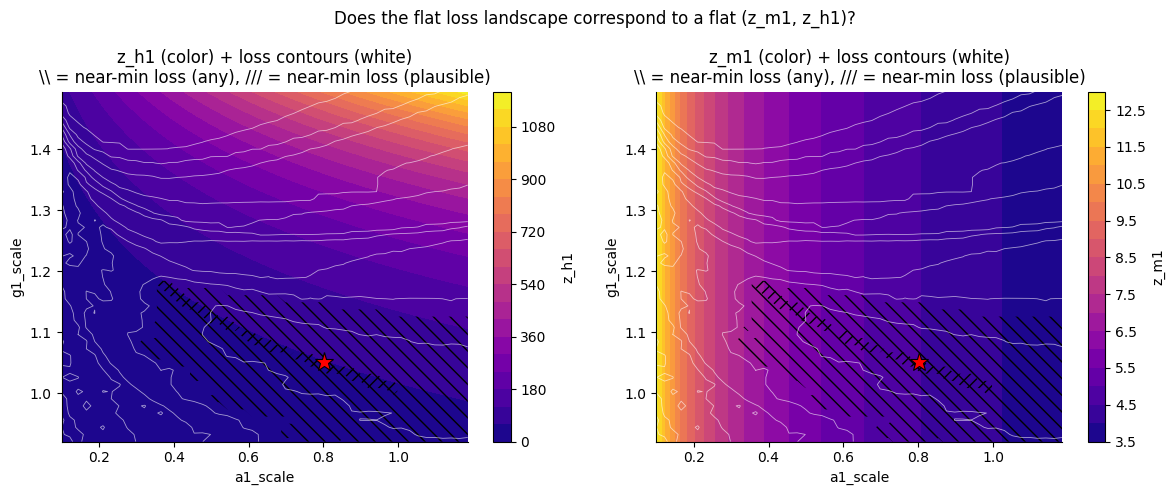

In [21]:
g0_here = 10.0 ** log_g0


def _pad_range(bounds, outer_bounds, frac=0.15):
    lo, hi = bounds
    pad = frac * max(hi - lo, 1e-6)
    return (max(outer_bounds[0], lo - pad), min(outer_bounds[1], hi + pad))


N_DEGEN_GRID = 50
a1_degen_vals = np.linspace(*_pad_range(A1_SCALE_BOUNDS_TIGHT, A1_SCALE_BOUNDS), N_DEGEN_GRID)
g1_degen_vals = np.linspace(*_pad_range(G1_SCALE_BOUNDS_TIGHT, G1_SCALE_BOUNDS), N_DEGEN_GRID)
loss21_degen = loss_grid_intervention(a0, log_g0, sigma, T_SWITCH_21, auxin21_curve,
                                       a1_degen_vals, g1_degen_vals, seed=123)
A1_DEGEN, G1_DEGEN = np.meshgrid(a1_degen_vals, g1_degen_vals)

A1_PHYS = a0 * A1_DEGEN           # alpha_auxin21 at every grid point
G1_PHYS = g0_here ** G1_DEGEN     # g_auxin21 at every grid point
Z_H1_GRID = A1_PHYS / G1_PHYS
Z_M1_GRID = sigma / np.sqrt(A1_PHYS)

# "near-minimum" = within a fixed relative tolerance of the grid's own
# best loss. Reported two ways: (a) over *all* finite-loss points, which is
# literally the flat valley visible in the fig2a heatmap regardless of
# whether the hard plausibility constraint is satisfied there, and (b)
# restricted to the plausible region, which is what the fit is actually
# allowed to choose from.
NEAR_MIN_LOSS_TOL = 0.05  # 5% above the grid minimum; purely descriptive, not a formal CI
plausible_here = intervention_plausible_mask(a0, log_g0, sigma, A1_DEGEN, G1_DEGEN, Z_H_RANGE[1])
finite_loss = np.isfinite(loss21_degen)


def _report_near_min(mask, label):
    loss_min = np.nanmin(loss21_degen[mask]) if mask.any() else np.nan
    near = mask & (loss21_degen <= loss_min * (1.0 + NEAR_MIN_LOSS_TOL))
    print(f"[{label}] grid minimum loss = {loss_min:.4f}  "
          f"(Step 2 optimizer found {fit_auxin21['loss']:.4f} off-grid)")
    print(f"  near-minimum region: loss <= {loss_min * (1.0 + NEAR_MIN_LOSS_TOL):.4f} "
          f"({near.sum()} of {mask.sum()} grid points)")
    if near.any():
        print(f"    z_h1 range: [{Z_H1_GRID[near].min():.3f}, {Z_H1_GRID[near].max():.3f}]  "
              f"(fitted z_h1 = {fit_auxin21['z_h1']:.3f})")
        print(f"    z_m1 range: [{Z_M1_GRID[near].min():.3f}, {Z_M1_GRID[near].max():.3f}]  "
              f"(fitted z_m1 = {sigma / np.sqrt(fit_auxin21['a1']):.3f})")
        print(f"    a1 range:   [{A1_PHYS[near].min():.4f}, {A1_PHYS[near].max():.4f}]  "
              f"(fitted a1 = {fit_auxin21['a1']:.4f})")
    return near


near_min_all = _report_near_min(finite_loss, "ignoring plausibility -- raw loss valley")
near_min = _report_near_min(finite_loss & plausible_here, "plausible region only")

fig2b, axes2b = plt.subplots(1, 2, figsize=(12, 5))
for ax, GRID, label in zip(axes2b, [Z_H1_GRID, Z_M1_GRID], ["z_h1", "z_m1"]):
    cf2b = ax.contourf(A1_DEGEN, G1_DEGEN, GRID, levels=20, cmap="plasma")
    ax.contour(A1_DEGEN, G1_DEGEN, np.log10(loss21_degen + 1.0), levels=10, colors="white",
               linewidths=0.6, alpha=0.6)
    if near_min_all.any():
        ax.contourf(A1_DEGEN, G1_DEGEN, near_min_all.astype(float), levels=[0.5, 1.5],
                    colors=["none"], hatches=["\\\\"])
    if near_min.any():
        ax.contourf(A1_DEGEN, G1_DEGEN, near_min.astype(float), levels=[0.5, 1.5],
                    colors=["none"], hatches=["///"])
    ax.plot(a1_scale, g1_scale, "r*", ms=14, mec="black", mew=0.8)
    ax.set_xlabel("a1_scale")
    ax.set_ylabel("g1_scale")
    ax.set_title(f"{label} (color) + loss contours (white)\n"
                 f"\\\\ = near-min loss (any), /// = near-min loss (plausible)")
    fig2b.colorbar(cf2b, ax=ax, label=label)
fig2b.suptitle("Does the flat loss landscape correspond to a flat (z_m1, z_h1)?")
plt.tight_layout()
plt.show()

### Sanity-checking `_weighted_neg_log_lik` against the actual fits

Evaluated at each condition's already-fitted parameters, using enough
paths to be reasonably stable (`n_paths_final`-scale), just to confirm the
function runs end-to-end and returns finite, sensible numbers -- not used
to refit anything here.

In [22]:
g0_check = 10.0 ** log_g0
noise_dmso_check = _make_common_noise(3000, 0.1, dmso_curve["t_max"], seed=7)
T_dmso_check, _, _ = simulate_fpt_and_state(
    3000, a0, g0_check, sigma ** 2, a0 / g0_check, z0=0.0, dt=0.1,
    t_max=dmso_curve["t_max"], noise=noise_dmso_check,
)
nll_dmso_check = _weighted_neg_log_lik(T_dmso_check, dmso_curve, 3000)
loss_dmso_check = _weighted_log_loss(
    km_from_fpt(T_dmso_check, dmso_curve["t_emp"], t_max=dmso_curve["t_max"]),
    dmso_curve["S_emp"], dmso_curve["weight_emp"], 3000,
)
print(f"DMSO_day_10 at fitted (a0={a0:.4f}, log_g0={log_g0:.4f}, sigma={sigma:.4f}):")
print(f"  _weighted_neg_log_lik = {nll_dmso_check:.4f}   _weighted_log_loss = {loss_dmso_check:.4f}")

noise1_a21_check = _make_common_noise(3000, 0.1, T_SWITCH_21, seed=7)
noise2_a21_check = _make_common_noise(3000, 0.1, auxin21_curve["t_max"] - T_SWITCH_21, seed=8)
T_a21_check = simulate_two_phase(
    3000, a0, a0 / g0_check, fit_auxin21["a1"], fit_auxin21["z_h1"], sigma ** 2,
    T_SWITCH_21, auxin21_curve["t_max"], 0.1, noise1=noise1_a21_check, noise2=noise2_a21_check,
)
nll_a21_check = _weighted_neg_log_lik(T_a21_check, auxin21_curve, 3000)
loss_a21_check = _weighted_log_loss(
    km_from_fpt(T_a21_check, auxin21_curve["t_emp"], t_max=auxin21_curve["t_max"]),
    auxin21_curve["S_emp"], auxin21_curve["weight_emp"], 3000,
)
print(f"Auxin_day_21 at fitted (a1={fit_auxin21['a1']:.4f}, z_h1={fit_auxin21['z_h1']:.4f}):")
print(f"  _weighted_neg_log_lik = {nll_a21_check:.4f}   _weighted_log_loss = {loss_a21_check:.4f}")

DMSO_day_10 at fitted (a0=0.1553, log_g0=-2.5439, sigma=1.5941):
  _weighted_neg_log_lik = 407.1512   _weighted_log_loss = 266.9773
Auxin_day_21 at fitted (a1=0.1245, z_h1=58.7267):
  _weighted_neg_log_lik = 455.8392   _weighted_log_loss = 57.9794


## Trajectory plot -- `DMSO_day_10` -> `Auxin_day_21` switch

RMSE/KS on `S(t)` only checks the *population* curve; it can't tell you
whether the individual `z(t)` trajectories implied by the fitted
parameters are physically sensible -- e.g. an absorbing threshold `z_h`
that's ballooned to an implausible value (exactly the boundary-hugging
failure mode flagged above) can still produce a passable-looking survival
curve while the underlying trajectories are nonsense. This is the fast
visual check to run every time the Configuration cell's bounds are
adjusted, before trusting a fit based on RMSE/KS alone.

Trajectory fates (N=40):  died stage 1 = 27,  died stage 2 = 10,  survived = 3


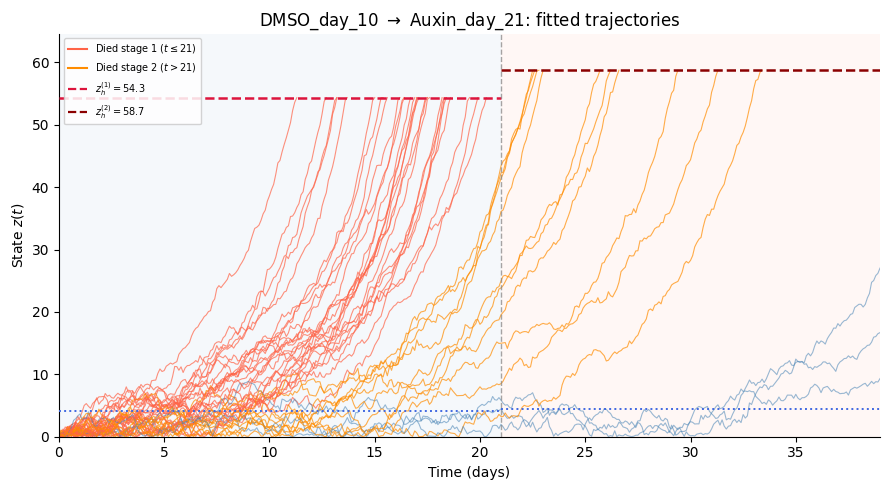

In [23]:
def _death_times_from_trajectories(t_grid, z_paths):
    """First NaN time per column of z_paths, or NaN if that column survived."""
    is_nan = np.isnan(z_paths)
    has_died = is_nan.any(axis=0)
    first_nan_idx = np.argmax(is_nan, axis=0)
    return np.where(has_died, t_grid[first_nan_idx], np.nan)


g0 = 10.0 ** log_g0
z_h0 = a0 / g0
z_h1 = fit_auxin21["z_h1"]
a1 = fit_auxin21["a1"]

t_traj, z_traj = simulate_two_phase_trajectories(
    N_TRAJ, a0, z_h0, a1, z_h1, sigma ** 2,
    T_SWITCH_21, auxin21_curve["t_max"], DT_TRAJ, rng=np.random.default_rng(42),
)

t_death_traj = _death_times_from_trajectories(t_traj, z_traj)
died_s1 = (~np.isnan(t_death_traj)) & (t_death_traj <= T_SWITCH_21)
died_s2 = (~np.isnan(t_death_traj)) & (t_death_traj > T_SWITCH_21)
survived = np.isnan(t_death_traj)

print(f"Trajectory fates (N={N_TRAJ}):  died stage 1 = {died_s1.sum()},  "
      f"died stage 2 = {died_s2.sum()},  survived = {survived.sum()}")

z_ylim = z_h1 * 1.10
fig_traj, ax_t = plt.subplots(figsize=(9, 5))

ax_t.axvspan(0, T_SWITCH_21, alpha=0.05, color="steelblue", lw=0)
ax_t.axvspan(T_SWITCH_21, auxin21_curve["t_max"], alpha=0.05, color="tomato", lw=0)

for k in range(N_TRAJ):
    z_k = z_traj[:, k]
    mask = ~np.isnan(z_k)
    if mask.sum() < 2:
        continue
    if died_s1[k]:
        col, alph = "tomato", 0.70
    elif died_s2[k]:
        col, alph = "darkorange", 0.70
    else:
        col, alph = "steelblue", 0.55
    ax_t.plot(t_traj[mask], z_k[mask], color=col, lw=0.8, alpha=alph, zorder=2)

ax_t.hlines(sigma / np.sqrt(a0), 0, T_SWITCH_21, colors="royalblue", lw=1.4, ls=":", zorder=3)
ax_t.hlines(sigma / np.sqrt(a1), T_SWITCH_21, auxin21_curve["t_max"], colors="royalblue", lw=1.4, ls=":", zorder=3)
ax_t.hlines(z_h0, 0, T_SWITCH_21, colors="crimson", lw=1.8, ls="--", zorder=4)
ax_t.hlines(z_h1, T_SWITCH_21, auxin21_curve["t_max"], colors="darkred", lw=1.8, ls="--", zorder=4)
ax_t.axvline(T_SWITCH_21, color="gray", lw=1.0, ls="--", alpha=0.7, zorder=5)

legend_handles = [
    Line2D([0], [0], color="tomato", lw=1.5, label=f"Died stage 1 ($t \\leq {T_SWITCH_21:.0f}$)"),
    Line2D([0], [0], color="darkorange", lw=1.5, label=f"Died stage 2 ($t > {T_SWITCH_21:.0f}$)"),
    Line2D([0], [0], color="crimson", lw=1.6, ls="--", label=f"$z_h^{{(1)}}={z_h0:.1f}$"),
    Line2D([0], [0], color="darkred", lw=1.6, ls="--", label=f"$z_h^{{(2)}}={z_h1:.1f}$"),
]
ax_t.legend(handles=legend_handles, fontsize=7, loc="upper left", frameon=True, framealpha=0.85)
ax_t.set_xlabel("Time (days)")
ax_t.set_ylabel("State $z(t)$")
ax_t.set_title("DMSO_day_10 $\\to$ Auxin_day_21: fitted trajectories")
ax_t.set_xlim(0, auxin21_curve["t_max"])
ax_t.set_ylim(0, z_ylim)
plt.tight_layout()
plt.show()

## Validation -- fitted curves vs. real KM curves, all three conditions

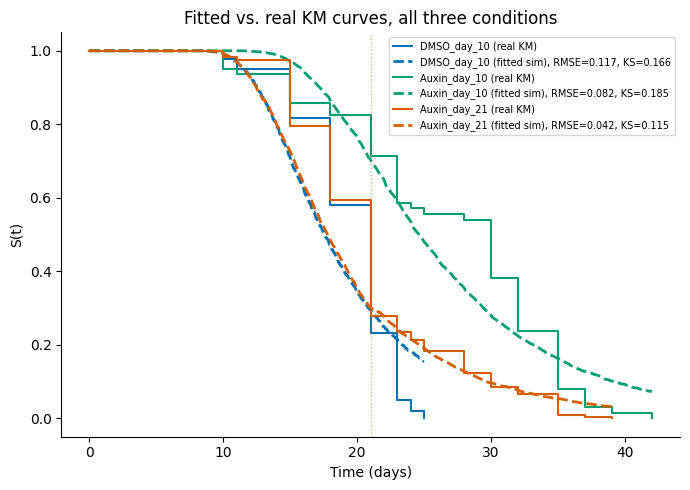

In [24]:
COLORS = {"DMSO_day_10": "#0072B2", "Auxin_day_10": "#009E73", "Auxin_day_21": "#D55E00"}

fig, ax = plt.subplots(figsize=(7, 5))

# DMSO and Auxin_day_10: independent single-phase fits.
for name, cond, (a, log_g) in [
        ("DMSO_day_10", dmso_curve, (a0, log_g0)),
        ("Auxin_day_10", auxin10_curve, (a0_auxin10, log_g0_auxin10)),
]:
    color = COLORS[name]
    cond["kmf"].plot_survival_function(ax=ax, color=color, ci_show=False, label=f"{name} (real KM)")

    g = 10.0 ** log_g
    z_h = a / g
    t_plot = np.linspace(0, cond["t_max"], 400)
    T_sim, _, _ = simulate_fpt_and_state(
        N_VALIDATE, a, g, sigma ** 2, z_h, z0=0.0, dt=DT_VALIDATE, t_max=cond["t_max"],
        rng=np.random.default_rng(0),
    )
    S_sim_plot = km_from_fpt(T_sim, t_plot, t_max=cond["t_max"])
    S_sim_emp = km_from_fpt(T_sim, cond["t_emp"], t_max=cond["t_max"])
    gof = goodness_of_fit(S_sim_emp, cond["S_emp"])
    ax.plot(t_plot, S_sim_plot, color=color, ls="--", lw=2.0,
            label=f"{name} (fitted sim), RMSE={gof['rmse']:.3f}, KS={gof['ks']:.3f}")

# Auxin_day_21: two-phase fit.
color = COLORS["Auxin_day_21"]
auxin21_curve["kmf"].plot_survival_function(ax=ax, color=color, ci_show=False, label="Auxin_day_21 (real KM)")
g0 = 10.0 ** log_g0
z_h0 = a0 / g0
t_plot = np.linspace(0, auxin21_curve["t_max"], 400)
T_sim21 = simulate_two_phase(
    N_VALIDATE, a0, z_h0, fit_auxin21["a1"], fit_auxin21["z_h1"], sigma ** 2,
    T_SWITCH_21, auxin21_curve["t_max"], DT_VALIDATE,
)
S_sim21_plot = km_from_fpt(T_sim21, t_plot, t_max=auxin21_curve["t_max"])
S_sim21_emp = km_from_fpt(T_sim21, auxin21_curve["t_emp"], t_max=auxin21_curve["t_max"])
gof21 = goodness_of_fit(S_sim21_emp, auxin21_curve["S_emp"])
ax.plot(t_plot, S_sim21_plot, color=color, ls="--", lw=2.0,
        label=f"Auxin_day_21 (fitted sim), RMSE={gof21['rmse']:.3f}, KS={gof21['ks']:.3f}")
ax.axvline(T_SWITCH_21, color=color, lw=1, ls=":", alpha=0.5)

ax.set_xlabel("Time (days)")
ax.set_ylabel("S(t)")
ax.set_title("Fitted vs. real KM curves, all three conditions")
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Summary

In [25]:
print("Automatically fitted parameters for the switching Langevin model:")
print(f"  a0       = {a0:.4f}")
print(f"  log_g0   = {log_g0:.4f}")
print(f"  g1_scale = {g1_scale:.4f}")
print(f"  a1_scale = {a1_scale:.4f}")
print(f"  sigma    = {sigma:.4f}")
print()
print("Auxin_day_10's own independent parameters (not part of the 5 above --")
print("Auxin_day_10 needs to be simulated as its own single-phase")
print("population, not a switch from DMSO):")
print(f"  a0_auxin10     = {a0_auxin10:.4f}")
print(f"  log_g0_auxin10 = {log_g0_auxin10:.4f}")

Automatically fitted parameters for the switching Langevin model:
  a0       = 0.1553
  log_g0   = -2.5439
  g1_scale = 1.0510
  a1_scale = 0.8017
  sigma    = 1.5941

Auxin_day_10's own independent parameters (not part of the 5 above --
Auxin_day_10 needs to be simulated as its own single-phase
population, not a switch from DMSO):
  a0_auxin10     = 0.1035
  log_g0_auxin10 = -2.7358
